# Chemprop-based Tg Prediction
This notebook trains ensembles of MPNN models for polymer glass transition temperature (Tg) prediction. It compares feature usage and loss functions, quantifies uncertainty and performs applicability domain analysis.

**Summary:**
1. Train ensembles of 100 MPNN models (50 epochs, lr=0.001) with and without features.
2. Use RegressionFFN, train without validation set.
3. Compare RMSE and MSE as loss functions.
4. Quantify uncertainty (epistemic/model and aleatoric/data noise).
5. Compare all 4 cases (with/without features × RMSE/MSE) on train and test sets.
6. Save all model in the ensembles.
7. Perform applicability domain analysis using hidden representation feature vectors

In [1]:
# import necessary libraries
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import hjson

In [2]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import mahalanobis

from lightning import pytorch as pl

from chemprop import data, featurizers, models, nn, utils, uncertainty
from chemprop.models.utils import save_model, load_model
from chemprop.nn.metrics import RMSE, MSE

Setting up local imports of custom python functions

In [3]:
# Ensure project root is on path (one level up from 'development')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Also add the shared directory so that `utils` package can be resolved (matches streamlit_app logic)
SHARED_DIR = PROJECT_ROOT / 'shared'
print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor


In [4]:
from src.base_uilts import get_performance_metrics, plot_xy_trend

In [5]:
figs_dir = PROJECT_ROOT / "figs" 

# 1. Data Processing
## Reading data
First we read data for SMILES notation and corresponding log(Tg) value for all 902 polymers

In [6]:
input_data_path = PROJECT_ROOT / 'data' / 'processed' / 'Tg_vs_SMILES_all.csv'
df_input = pd.read_csv(input_data_path)
print("Data-frame shape", df_input.shape)
df_input.head()

Data-frame shape (902, 11)


,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC
3,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F
4,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N


In [7]:
smiles_column = 'SMILES_clean' # column with SMILES notation strings
target_column = ['logTg'] # column with target variable value

## Adding physics-based descriptors
* Free volume proxy (using van der Waals volume)
* Chain flexibility (number of rotatable bonds)
* Aromatic content (number of aromatic rings)
* Polarity (TPSA / dipole moment proxy)
* Hydrogen bond donor/acceptor count
* Molecular weight (exact or monomer-based)

I created a custom function that use RDKit on the backend to create the above-described features.

In [8]:
from rdkit.Chem import Descriptors, rdMolDescriptors, MolFromSmiles

def compute_descriptors(smiles):
    """Compute molecular descriptors for a given SMILES string.

    Args:
        smiles (str): The SMILES representation of the molecule.

    Returns:
        descriptors (dict): A dictionary containing the computed molecular descriptors.
            keys include:
                - 'Moleculer Weight': Molecular Weight. 
                - 'Proxy for Free Volume': Proxy for free volume.
                - 'Rotatable Bonds': Number of Rotatable Bonds.
                - 'Aromatic Rings': Number of Aromatic Rings.
                - 'Topological Polar Surface Area': Topological Polar Surface Area.
                - 'H-Bond Donors': Number of Hydrogen Bond Donors.
                - 'H-Bond Acceptors': Number of Hydrogen Bond Acceptors
    """
    # Compute molecular descriptors
    mol = MolFromSmiles(smiles)
    # Check if the molecule was successfully created
    if mol is None:
        raise ValueError(f"Invalid SMILES string: {smiles}")

    # Compute molecular descriptors
    descriptors = {
        'Moleculer Weight': Descriptors.MolWt(mol),
        'Proxy for Free Volume': rdMolDescriptors.CalcExactMolWt(mol) / rdMolDescriptors.CalcNumHeavyAtoms(mol),
        'Rotatable Bonds':  Descriptors.NumRotatableBonds(mol),
        'Aromatic Rings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'Topological Polar Surface Area': Descriptors.TPSA(mol),
        'H-Bond Donors': rdMolDescriptors.CalcNumHBD(mol),
        'H-Bond Acceptors': rdMolDescriptors.CalcNumHBA(mol)
    }

    return descriptors

In [9]:
# data-frame with molecule-level descriptor data
descriptors_df = pd.DataFrame(
    list(df_input[smiles_column].apply(compute_descriptors))
)
print("Descriptors data-frame shape", descriptors_df.shape)
descriptors_df.head()

Descriptors data-frame shape (902, 7)


,Moleculer Weight,Proxy for Free Volume,Rotatable Bonds,Aromatic Rings,Topological Polar Surface Area,H-Bond Donors,H-Bond Acceptors
0,88.537,17.601596,1,0,0.00,0,0
1,71.079,14.207423,1,0,43.09,1,1
2,153.181,13.916271,4,0,50.09,0,3
3,186.104,15.502533,4,0,26.30,0,2
4,111.100,13.879004,2,0,50.09,0,3


In [10]:
n_descriptors = descriptors_df.shape[1]
print("Number of descriptors per polymer:", n_descriptors)

Number of descriptors per polymer: 7


In [11]:
descriptor_list = descriptors_df.columns.tolist()
descriptor_list

['Moleculer Weight',
 'Proxy for Free Volume',
 'Rotatable Bonds',
 'Aromatic Rings',
 'Topological Polar Surface Area',
 'H-Bond Donors',
 'H-Bond Acceptors']

adding descriptors data-frame to the one containing SMILES notation and log(Tg) values

In [12]:
df_input_w_features = pd.concat(
    [df_input, descriptors_df],
    axis=1
)
print("Final data-frame shape containing all data", df_input_w_features.shape)
df_input_w_features.head()

Final data-frame shape containing all data (902, 18)


,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean,Moleculer Weight,Proxy for Free Volume,Rotatable Bonds,Aromatic Rings,Topological Polar Surface Area,H-Bond Donors,H-Bond Acceptors
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl,88.537,17.601596,1,0,0.00,0,0
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O,71.079,14.207423,1,0,43.09,1,1
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC,153.181,13.916271,4,0,50.09,0,3
3,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F,186.104,15.502533,4,0,26.30,0,2
4,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N,111.100,13.879004,2,0,50.09,0,3


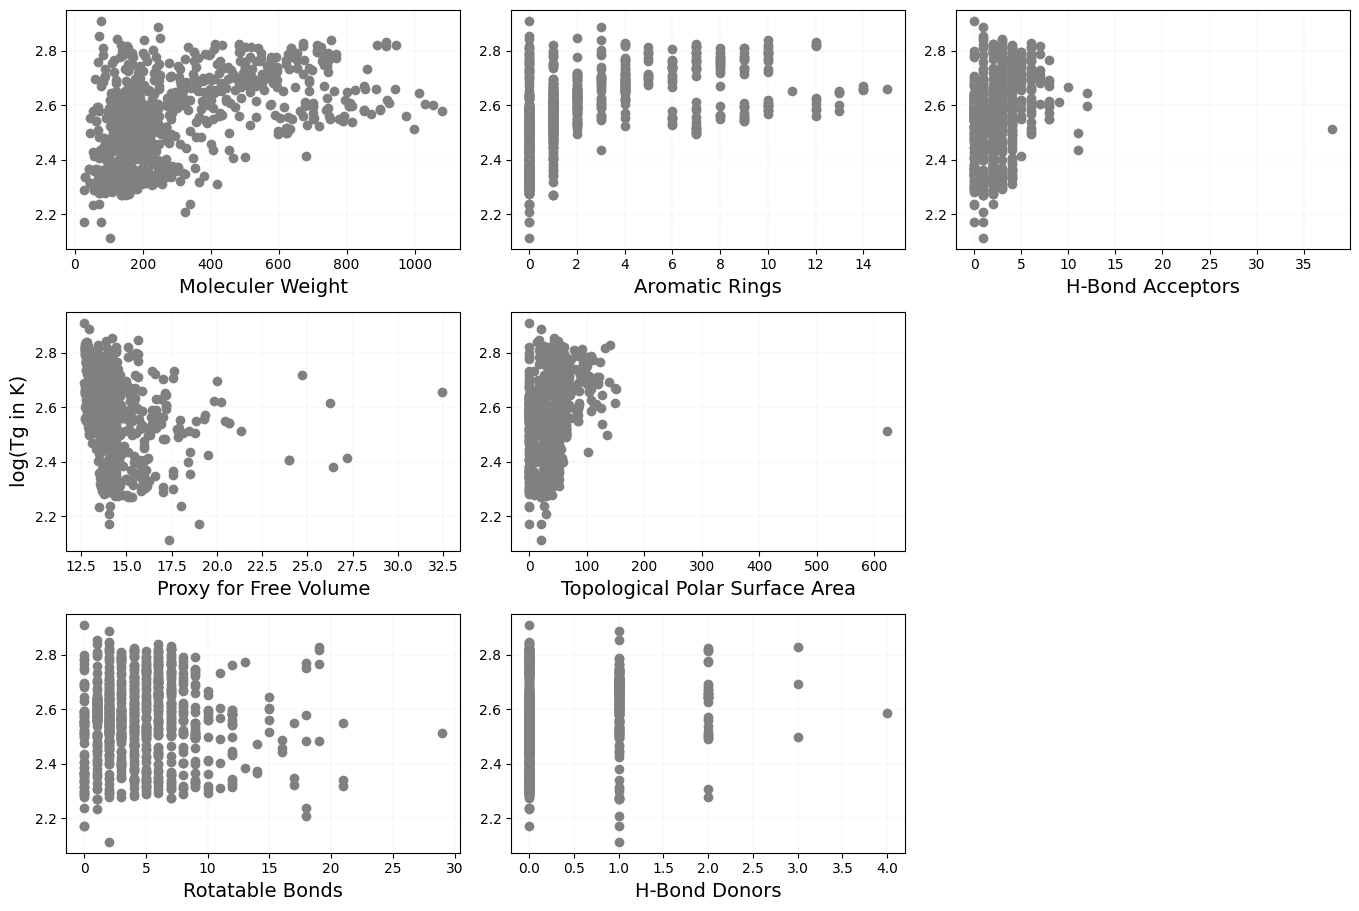

In [146]:
# Plot correlation between each feature and target variable
# Set figure size in inches (width, height)
fig, ax = plt.subplots(3, 3, figsize=(13.7, 9.21))  # 348mm x 234mm
plt_n_ = 3
for i, feat_ in enumerate(descriptor_list):
    ax[i%plt_n_][int(i/plt_n_)].scatter(
        df_input_w_features[feat_], df_input_w_features[target_column], color='gray'
    )
    if (i % plt_n_ == 1) & (int(i/plt_n_) == 0):
        ax[i%plt_n_][int(i/plt_n_)].set_ylabel("log(Tg in K)", fontsize=14)
    ax[i%plt_n_][int(i/plt_n_)].set_xlabel(feat_, fontsize=14)
    ax[i%plt_n_][int(i/plt_n_)].grid(True, which='both', linestyle='--', linewidth=0.1)
    
ax[1][2].set_visible(False)
ax[2][2].set_visible(False)
plt.tight_layout()
# Save as EPS
plt.savefig(figs_dir / 'correlation_log_Tg_physical_descriptors.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()

In [14]:
# saving training data-table with smiles notation and descriptor values
df_input_w_features.to_csv(
    PROJECT_ROOT / 'data' / 'processed' / 'Tg_vs_SMILES_plus_descriptors_all.csv',
    index=False
)

## Splitting training & testing datasets
Now we prepare data-set to be provided to neural network for model training

In [15]:
# get data-frame with training data IDs
train_df = pd.read_csv(
    PROJECT_ROOT / 'data' / 'raw' / 'data_902_original_15desc_logTg_train.csv'
)

In [16]:
# filter input table with IDs within training set
df_smiles_train = df_input_w_features[
    df_input_w_features['ID'].isin(train_df['Index'])
].reset_index(drop=True)

print("Training data-frame w/ SMILES notation", df_smiles_train.shape)

# using rest of them for independent testing of the model performance
df_smiles_test = df_input_w_features[
    ~df_input_w_features['ID'].isin(train_df['Index'])
].reset_index(drop=True)

print("Training data-frame w/ SMILES notation", df_smiles_test.shape)

Training data-frame w/ SMILES notation (683, 18)
Training data-frame w/ SMILES notation (219, 18)


In [17]:
# converting input data to numpy array for downstream processing
train_smis = df_smiles_train.loc[:, smiles_column].values
print("Training data input smiles array shape", train_smis.shape)
print(train_smis[:5])

test_smis = df_smiles_test[smiles_column]
print("Testing data input smiles array shape", train_smis.shape)
print(test_smis[:5])

Training data input smiles array shape (683,)
['C=CC(=C)Cl' 'C=CC(N)=O' 'C=CC(=O)OCC(C#N)CC' 'C=CC(=O)OCC#N'
 'C=CC(=O)OCCCCCCCCCCCCCCCCCC']
Testing data input smiles array shape (683,)
0    C=CC(=O)OCC(F)(F)C(F)F
1               C=CC(C)(C)C
2      C=C(CC(=O)OC)C(=O)OC
3                C=CC(=O)CC
4                    C=CSCC
Name: SMILES_clean, dtype: object


In [147]:
df_smiles_test.head()

,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean,Moleculer Weight,Proxy for Free Volume,Rotatable Bonds,Aromatic Rings,Topological Polar Surface Area,H-Bond Donors,H-Bond Acceptors
0,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F,186.104,15.502533,4,0,26.30,0,2
1,8,PPD_043,2.7854,P,A,1-(tert-butyl)ethene,CC(C)(C)C=C,ChemAxon,CC(C)(C)C=C,1-(tert-butyl)ethene,C=CC(C)(C)C,84.162,14.015650,0,0,0.00,0,0
2,23,PPD_123,2.8103,P,A,dimethyl itaconate,COC(=O)CC(=C)C(=O)OC,PubChemPy,COC(=O)CC(=C)C(=O)OC,dimethyl itaconate,C=C(CC(=O)OC)C(=O)OC,158.153,14.368901,3,0,52.60,0,4
3,38,PPD_214,2.6868,P,A,vinyl ethyl ketone,CCC(=O)C=C,PubChemPy,CCC(=O)C=C,vinyl ethyl ketone,C=CC(=O)CC,84.118,14.009586,2,0,17.07,0,1
4,41,PPD_217,2.7317,P,A,ethyl vinyl thioether,CCSC=C,ChemAxon,CCSC=C,ethyl vinyl thioether,C=CSCC,88.175,17.606934,2,0,0.00,0,1


In [18]:
# converting additional descriptors data to numpy array
train_V_fs = df_smiles_train.loc[:, descriptor_list].values
print(train_V_fs.shape)

test_V_fs = df_smiles_test.loc[:, descriptor_list].values
print(test_V_fs.shape)

(683, 7)
(219, 7)


In [19]:
# converting target data to numpy array
train_ys = df_smiles_train.loc[:, target_column].values
print("Target value array shape", train_ys.shape)
train_ys[:5]

Target value array shape (683, 1)


array([[2.7077],
       [2.852 ],
       [2.8177],
       [2.7552],
       [2.7687]])

# 2. Directed-Message-Passing Neural Network (D-MPNN)
## Model explained

In [20]:
# create RDKit molecule objects from SMILES notation strings
train_mols = [
    utils.make_mol(smi, keep_h=False, add_h=False) for smi in train_smis
]

# MoleculeDatapoints are made from target value(s) SMILES and additional descriptors. 
train_data = [
    data.MoleculeDatapoint(mol, y, x_d=X_d) for mol, y, X_d in zip(train_mols, train_ys, train_V_fs)
]

# featurizer to transforms molecules into molecular graphs where atoms become nodes and bonds become edges
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

# define dataset of molecules and it's features
train_dset = data.MoleculeDataset(train_data, featurizer)

# normalizing target variable values for better model fit
scaler = train_dset.normalize_targets()

# define a data loader to be passed to the neural network
train_loader = data.build_dataloader(
    train_dset, # training dataset of molecules
    batch_size=64, # count of data-points to use in each training iteration
    num_workers=20 # number of workers for multi-processing
)

1. Construct a molecular graph using message passing to learn,

a. Bond-level hidden representations

In [21]:
nn.BondMessagePassing

chemprop.nn.message_passing.base.BondMessagePassing

In [22]:
nn.BondMessagePassing()

BondMessagePassing(
  (W_i): Linear(in_features=86, out_features=300, bias=False)
  (W_h): Linear(in_features=300, out_features=300, bias=False)
  (W_o): Linear(in_features=372, out_features=300, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (tau): ReLU()
  (V_d_transform): Identity()
  (graph_transform): Identity()
)

b. Atom-level hidden representations

In [23]:
nn.AtomMessagePassing

chemprop.nn.message_passing.base.AtomMessagePassing

In [24]:
nn.AtomMessagePassing()

AtomMessagePassing(
  (W_i): Linear(in_features=72, out_features=300, bias=False)
  (W_h): Linear(in_features=314, out_features=300, bias=False)
  (W_o): Linear(in_features=372, out_features=300, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (tau): ReLU()
  (V_d_transform): Identity()
  (graph_transform): Identity()
)

2. An Aggregation is responsible for constructing a graph-level representation from the set of node-level representations after message passing. Available options can be found in

In [25]:
print(nn.agg.AggregationRegistry)

ClassRegistry {
    'mean': <class 'chemprop.nn.agg.MeanAggregation'>,
    'sum': <class 'chemprop.nn.agg.SumAggregation'>,
    'norm': <class 'chemprop.nn.agg.NormAggregation'>
}


3. Feed-forward regression network:  A FFN takes the aggregated representations and make target predictions. In addition to the dimension of hidden representations from MP network i.e. 300, additional 7 dimensions as input. This makes a total of 307 dimensional vector passed to FNN as input.

In [26]:
print(nn.PredictorRegistry)

ClassRegistry {
    'regression': <class 'chemprop.nn.predictors.RegressionFFN'>,
    'regression-mve': <class 'chemprop.nn.predictors.MveFFN'>,
    'regression-evidential': <class 'chemprop.nn.predictors.EvidentialFFN'>,
    'regression-quantile': <class 'chemprop.nn.predictors.QuantileFFN'>,
    'classification': <class 'chemprop.nn.predictors.BinaryClassificationFFN'>,
    'classification-dirichlet': <class 'chemprop.nn.predictors.BinaryDirichletFFN'>,
    'multiclass': <class 'chemprop.nn.predictors.MulticlassClassificationFFN'>,
    'multiclass-dirichlet': <class 'chemprop.nn.predictors.MulticlassDirichletFFN'>,
    'spectral': <class 'chemprop.nn.predictors.SpectralFFN'>
}


4. Loss functions: The derivatives of these differentiable functions are used to update the model weights. Users only need to select the loss function to use. The rest of the details are handled by Chemprop and the lightning trainer, which reports the training and validation loss during model fitting.



In [27]:
print(nn.metrics.LossFunctionRegistry)

ClassRegistry {
    'mse': <class 'chemprop.nn.metrics.MSE'>,
    'mae': <class 'chemprop.nn.metrics.MAE'>,
    'rmse': <class 'chemprop.nn.metrics.RMSE'>,
    'bounded-mse': <class 'chemprop.nn.metrics.BoundedMSE'>,
    'bounded-mae': <class 'chemprop.nn.metrics.BoundedMAE'>,
    'bounded-rmse': <class 'chemprop.nn.metrics.BoundedRMSE'>,
    'mve': <class 'chemprop.nn.metrics.MVELoss'>,
    'evidential': <class 'chemprop.nn.metrics.EvidentialLoss'>,
    'bce': <class 'chemprop.nn.metrics.BCELoss'>,
    'ce': <class 'chemprop.nn.metrics.CrossEntropyLoss'>,
    'binary-mcc': <class 'chemprop.nn.metrics.BinaryMCCLoss'>,
    'multiclass-mcc': <class 'chemprop.nn.metrics.MulticlassMCCLoss'>,
    'dirichlet': <class 'chemprop.nn.metrics.DirichletLoss'>,
    'sid': <class 'chemprop.nn.metrics.SID'>,
    'earthmovers': <class 'chemprop.nn.metrics.Wasserstein'>,
    'wasserstein': <class 'chemprop.nn.metrics.Wasserstein'>,
    'quantile': <class 'chemprop.nn.metrics.QuantileLoss'>,
    'pinbal

In [28]:
print(uncertainty.UncertaintyEstimatorRegistry)

ClassRegistry {
    'none': <class 'chemprop.uncertainty.estimator.NoUncertaintyEstimator'>,
    'mve': <class 'chemprop.uncertainty.estimator.MVEEstimator'>,
    'ensemble': <class 'chemprop.uncertainty.estimator.EnsembleEstimator'>,
    'classification': <class 'chemprop.uncertainty.estimator.ClassEstimator'>,
    'evidential-total': <class 'chemprop.uncertainty.estimator.EvidentialTotalEstimator'>,
    'evidential-epistemic': <class 'chemprop.uncertainty.estimator.EvidentialEpistemicEstimator'>,
    'evidential-aleatoric': <class 'chemprop.uncertainty.estimator.EvidentialAleatoricEstimator'>,
    'dropout': <class 'chemprop.uncertainty.estimator.DropoutEstimator'>,
    'classification-dirichlet': <class 'chemprop.uncertainty.estimator.ClassificationDirichletEstimator'>,
    'multiclass-dirichlet': <class 'chemprop.uncertainty.estimator.MulticlassDirichletEstimator'>,
    'quantile-regression': <class 'chemprop.uncertainty.estimator.QuantileRegressionEstimator'>
}


In [29]:
uncertainty

<module 'chemprop.uncertainty' from '/home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/chemprop/uncertainty/__init__.py'>

**Defining a D-MPNN model**

In [30]:
# message passing network that passes messages along bonds
mp = nn.BondMessagePassing()
# aggregation step as mean pooling
agg = nn.MeanAggregation()
# batch normalization for better training
batch_norm = True

# transform that can be used to unscale model outputs
output_transform = nn.UnscaleTransform.from_standard_scaler(scaler)
# loss function for training
loss_criterion = RMSE()  # Root Mean Square Error loss function

print("Output number of dimensions from Bond-message passing network", mp.output_dim)
# total dimensions of the features then passed to FFN
ffn_input_dim = mp.output_dim + train_V_fs.shape[1]
# creating Feed-Forward Network (FFN) for final property prediction
ffn = nn.RegressionFFN(
    input_dim=ffn_input_dim,
    output_transform=output_transform,
    criterion=loss_criterion,
)

# total dimensions of the features then passed to FFN 
print('FFN created with input_dim =', ffn.input_dim)

# Extra-descriptors are added to the model as normalized scalers
extra_datapoint_descriptors_scaler = train_dset.normalize_inputs("X_d")
# transform to normalize extra-descriptors
X_d_transform = nn.ScaleTransform.from_standard_scaler(extra_datapoint_descriptors_scaler)

# Finally putting all pieces together to define a MPNN model.
mpnn = models.MPNN(
    mp,
    agg,
    ffn,
    batch_norm,
    X_d_transform=X_d_transform
)

Output number of dimensions from Bond-message passing network 300
FFN created with input_dim = 307


In [31]:
mpnn

MPNN(
  (message_passing): BondMessagePassing(
    (W_i): Linear(in_features=86, out_features=300, bias=False)
    (W_h): Linear(in_features=300, out_features=300, bias=False)
    (W_o): Linear(in_features=372, out_features=300, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (tau): ReLU()
    (V_d_transform): Identity()
    (graph_transform): Identity()
  )
  (agg): MeanAggregation()
  (bn): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (predictor): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=307, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=1, bias=True)
      )
    )
    (criterion): RMSE(task_weights=[[1.0]])
    (output_transform): UnscaleTransform()
  )
  (X_d_transform): ScaleTransform()
  (metrics): ModuleList(
    (0): MSE(task_weights=[[1.0]])
    (1): RMSE(tas

Defining a trainer object to perform model training.

Use `True` if you want to save model checkpoints. The checkpoints will be saved in the `checkpoints` folder.

In [32]:
trainer = pl.Trainer(
    logger=False,
    enable_checkpointing=False, # 
    enable_progress_bar=True,
    accelerator="auto",
    devices=1, # 
    max_epochs=50, # number of epochs to train for
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


run trainer using the defined neural network and training data-loader

In [33]:
trainer.fit(
    mpnn, train_loader
)

/home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor/venv_Tg_predictor/lib/python3.12/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device 

Epoch 49: 100%|██████████| 11/11 [00:00<00:00, 23.55it/s, train_loss_step=0.245, train_loss_epoch=0.235]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 11/11 [00:00<00:00, 23.53it/s, train_loss_step=0.245, train_loss_epoch=0.235]


Looking at training loss metrics

In [34]:
trainer.callback_metrics

{'train_loss': tensor(0.2350),
 'train_loss_step': tensor(0.2454),
 'train_loss_epoch': tensor(0.2350)}

## Training Ensemble of Models
Train an ensemble of MPNN models for each configuration.

In [35]:
def train_mpnn_ensemble(
    train_smis,
    train_ys,
    loss_fn="rmse",
    train_V_fs=None,
    n_models=100,
    epochs=50,
    batch_size=64,
    num_workers=4,
    val_split=0.1,
    seed_control=True,
    cache_dir="./cache"
):
    """
    Train an ensemble of Chemprop-based Directed Message-Passing Neural Networks (D-MPNNs).

    Parameters
    ----------
    train_smis : np.ndarray
        Array of SMILES strings for training.
    train_ys : np.ndarray
        Array of target values for training.
    train_V_fs : np.ndarray, optional
        Optional array of additional feature descriptors.
    loss_fn : {'rmse','mse'}, default='rmse'
        Loss function used for training.
    n_models : int, default=100
        Number of ensemble members.
    epochs : int, default=50
        Training epochs for each model.
    batch_size : int, default=64
        Mini-batch size.
    num_workers : int, default=4
        Dataloader worker processes.
    val_split : float, default=0.1
        Fraction of data reserved for validation.
    seed_control : bool, default=True
        If True, store a random seed per model for reproducibility.
    cache_dir : str, default='./cache'
        Directory to store cached molecule graphs.

    Returns
    -------
    ensemble : list[chemprop.models.MPNN]
        List of trained Chemprop MPNN models.
    """

    os.makedirs(cache_dir, exist_ok=True)
    ensemble = []

    # Precompute molecular graphs once to avoid redundant featurization
    cache_file = os.path.join(cache_dir, "train_mols.npy")
    if os.path.exists(cache_file):
        train_mols = np.load(cache_file, allow_pickle=True)
    else:
        train_mols = [
            utils.make_mol(smi, keep_h=False, add_h=False)
            for smi in train_smis
        ]
        np.save(cache_file, np.array(train_mols, dtype=object))

    # Define loss criterion
    loss_criterion = RMSE() if loss_fn.lower() == "rmse" else MSE()

    # Build datasets (with or without descriptors)
    def build_dataset(train_idxs, val_idxs):
        if train_V_fs is not None:
            train_data = [data.MoleculeDatapoint(train_mols[i], train_ys[i], x_d=train_V_fs[i])
                          for i in train_idxs]
            val_data = [data.MoleculeDatapoint(train_mols[i], train_ys[i], x_d=train_V_fs[i])
                        for i in val_idxs]
        else:
            train_data = [data.MoleculeDatapoint(train_mols[i], train_ys[i]) for i in train_idxs]
            val_data = [data.MoleculeDatapoint(train_mols[i], train_ys[i]) for i in val_idxs]
        featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
        return (data.MoleculeDataset(train_data, featurizer),
                data.MoleculeDataset(val_data, featurizer))

    # Split train/validation indices
    n_samples = len(train_smis)
    all_idxs = np.arange(n_samples)
    val_size = int(val_split * n_samples)
    rng = np.random.default_rng(42)
    val_idxs = rng.choice(all_idxs, size=val_size, replace=False)
    train_idxs = np.setdiff1d(all_idxs, val_idxs)

    for m in tqdm(range(n_models), desc="Training ensemble", leave=False):
        # control randomness
        if seed_control:
            seed = np.random.randint(0, 1_000_000)
            pl.seed_everything(seed)
        else:
            seed = None

        train_dset, val_dset = build_dataset(train_idxs, val_idxs)

        scaler = train_dset.normalize_targets()
        output_transform = nn.UnscaleTransform.from_standard_scaler(scaler)
        mp = nn.BondMessagePassing()
        agg = nn.MeanAggregation()
        batch_norm = True

        input_dim = mp.output_dim
        X_d_transform = None
        if train_V_fs is not None:
            input_dim += train_V_fs.shape[1]
            x_scaler = train_dset.normalize_inputs("X_d")
            X_d_transform = nn.ScaleTransform.from_standard_scaler(x_scaler)

        ffn = nn.RegressionFFN(
            input_dim=input_dim,
            output_transform=output_transform,
            criterion=loss_criterion,
        )
        mpnn = models.MPNN(
            message_passing=mp,
            agg=agg,
            predictor=ffn,
            batch_norm=batch_norm,
            X_d_transform=X_d_transform,
        )

        train_loader = data.build_dataloader(
            train_dset,
            batch_size=batch_size,
            num_workers=num_workers,
            shuffle=True,
        )
        val_loader = data.build_dataloader(
            val_dset,
            batch_size=batch_size,
            num_workers=num_workers,
            shuffle=False,
        )

        trainer = pl.Trainer(
            accelerator="auto",
            devices=1,
            max_epochs=epochs,
            logger=False,
            enable_checkpointing=False,
            enable_progress_bar=False,
        )

        trainer.fit(mpnn, train_loader, val_loader)
        mpnn.seed = seed  # record seed for reproducibility
        ensemble.append(mpnn)

    return ensemble

Train ensembles for:
- With features, MSE loss
- With features, RMSE loss
- Without features, MSE loss
- Without features, RMSE loss

In [36]:
# # emsemble models with different configurations
print("Training ensembles of models")
n_models = 100

Training ensembles of models


In [37]:
# ## with features and mse loss function
# print('With features and mse loss function')
# ensemble_with_features_mse = train_mpnn_ensemble(
#     train_smis=train_smis,
#     train_ys=train_ys,
#     train_V_fs=train_V_fs,
#     loss_fn='mse',
#     n_models=n_models,
# )
# # with features and rmse loss function
# print('With features and rmse loss function')
# ensemble_with_features_rmse = train_mpnn_ensemble(
#     train_smis=train_smis,
#     train_ys=train_ys,
#     train_V_fs=train_V_fs,
#     loss_fn='rmse',
#     n_models=n_models,
# )
# # without features and mse loss function
# print('Without features and mse loss function')
# ensemble_no_features_mse = train_mpnn_ensemble(
#     train_smis=train_smis,
#     train_ys=train_ys,
#     loss_fn='mse',
#     n_models=n_models,
# )
# # without features and rmse loss function
# print('Without features and rmse loss function')
# ensemble_no_features_rmse = train_mpnn_ensemble(
#     train_smis=train_smis,
#     train_ys=train_ys,
#     loss_fn='rmse',
#     n_models=n_models,
# )

## Save ensemble of models

In [38]:
model_save_folder_path = PROJECT_ROOT / 'data' / 'processed' /'chemprop_models'

In [39]:
# #
# os.mkdir(model_save_folder_path)
# #
# for name, ensemble in [
#     ('with_features_mse', ensemble_with_features_mse),
#     ('with_features_rmse', ensemble_with_features_rmse),
#     ('no_features_mse', ensemble_no_features_mse),
#     ('no_features_rmse', ensemble_no_features_rmse)
#  ]:
#     os.mkdir(model_save_folder_path / name )
#     #
#     n_models = len(ensemble)
#     #
#     for i in range(n_models):
#         model_save_path = model_save_folder_path / name / f'chemprop_mpnn_model_num_{i}.pickle'
#         # 
#         save_model(model_save_path, ensemble[i])

## Load Model

In [40]:
# load chemprop models
ensemble_with_features_mse = []
ensemble_with_features_rmse = []
ensemble_no_features_mse = []
ensemble_no_features_rmse = []
for i in range(n_models):
    ensemble_with_features_mse.append(
        load_model(model_save_folder_path / 'with_features_mse' / f'chemprop_mpnn_model_num_{i}.pickle')
    )
    ensemble_with_features_rmse.append(
        load_model(model_save_folder_path / 'with_features_rmse' / f'chemprop_mpnn_model_num_{i}.pickle')
    )
    ensemble_no_features_mse.append(
        load_model(model_save_folder_path / 'no_features_mse' / f'chemprop_mpnn_model_num_{i}.pickle')
    )
    ensemble_no_features_rmse.append(
        load_model(model_save_folder_path / 'no_features_rmse' / f'chemprop_mpnn_model_num_{i}.pickle')
    )

## Ensemble Prediction & Uncertainty Quantification
Compute mean prediction, epistemic (model) and aleatoric (data) uncertainty for each ensemble.

In [41]:
def ensemble_predict(
    ensemble,
    test_smis,
    test_V_fs=None,
    num_workers=20
):
    """
    Predict using ensemble of Chemprop models with uncertainty estimation
    Parameters:
        ensemble : list of trained Chemprop models
        test_smis (np.ndarray): Array of SMILES strings for testing.
        test_V_fs (np.ndarray, optional): Array of additional feature descriptors for testing.
    Returns:
        mean_pred : np.ndarray
            Mean predictions from the ensemble.
        epistemic_uncertainty : np.ndarray
            Epistemic uncertainty (model uncertainty) estimates.
        aleatoric_uncertainty : np.ndarray
            Aleatoric uncertainty (data noise) estimates.
    """
    # create list of molecule objects from SMILES strings
    test_mols = [
        utils.make_mol(smi, keep_h=False, add_h=False) for smi in test_smis
    ]
    # if additional features are to be used
    if test_V_fs is not None:
        # create MoleculeDatapoint objects with additional features
        test_data = [
            data.MoleculeDatapoint(mol, x_d=X_d) for mol, X_d in zip(test_mols, test_V_fs)
        ]
    else:
        # create MoleculeDatapoint objects without additional features
        test_data = [data.MoleculeDatapoint(mol) for mol in test_mols]
    
    # initialize featurizer and dataset
    featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
    test_dset = data.MoleculeDataset(test_data, featurizer)
    
    # create data loader
    test_loader = data.build_dataloader(
        test_dset,
        batch_size=len(test_smis),
        num_workers=num_workers,
        shuffle=False
    )
    # collect predictions from each model in the ensemble
    preds = []
    uncs = []
    trainer = pl.Trainer(
            accelerator='auto',
            devices=1,
            logger=False,
            enable_checkpointing=False,
            enable_progress_bar=False
    )
    # get predictions
    #pred = trainer.predict(model, test_loader)
    
    unc_estimator_ensemble = uncertainty.EnsembleEstimator()
    mean_pred, epistemic_uncertainty = unc_estimator_ensemble(test_loader, ensemble, trainer)
    
    return mean_pred, epistemic_uncertainty

### Training dataset

In [42]:
mean_pred_dict = {}
epistemic_unc_dict = {}
for name, ensemble, features in [
    ('with_features_mse', ensemble_with_features_mse, train_V_fs),
    ('with_features_rmse', ensemble_with_features_rmse, train_V_fs),
    ('no_features_mse', ensemble_no_features_mse, None),
    ('no_features_rmse', ensemble_no_features_rmse, None)
 ]:
    mean_pred, epistemic_unc = ensemble_predict(
        ensemble=ensemble,
        test_smis=train_smis,
        test_V_fs=features,
    )
    mean_pred_dict[name] = mean_pred
    epistemic_unc_dict[name] = epistemic_unc

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LO

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


R2-score:: 0.940
Root Mean Squared Error: 0.0350
R2-score:: 0.945
Root Mean Squared Error: 0.0337
R2-score:: 0.939
Root Mean Squared Error: 0.0352
R2-score:: 0.944
Root Mean Squared Error: 0.0338


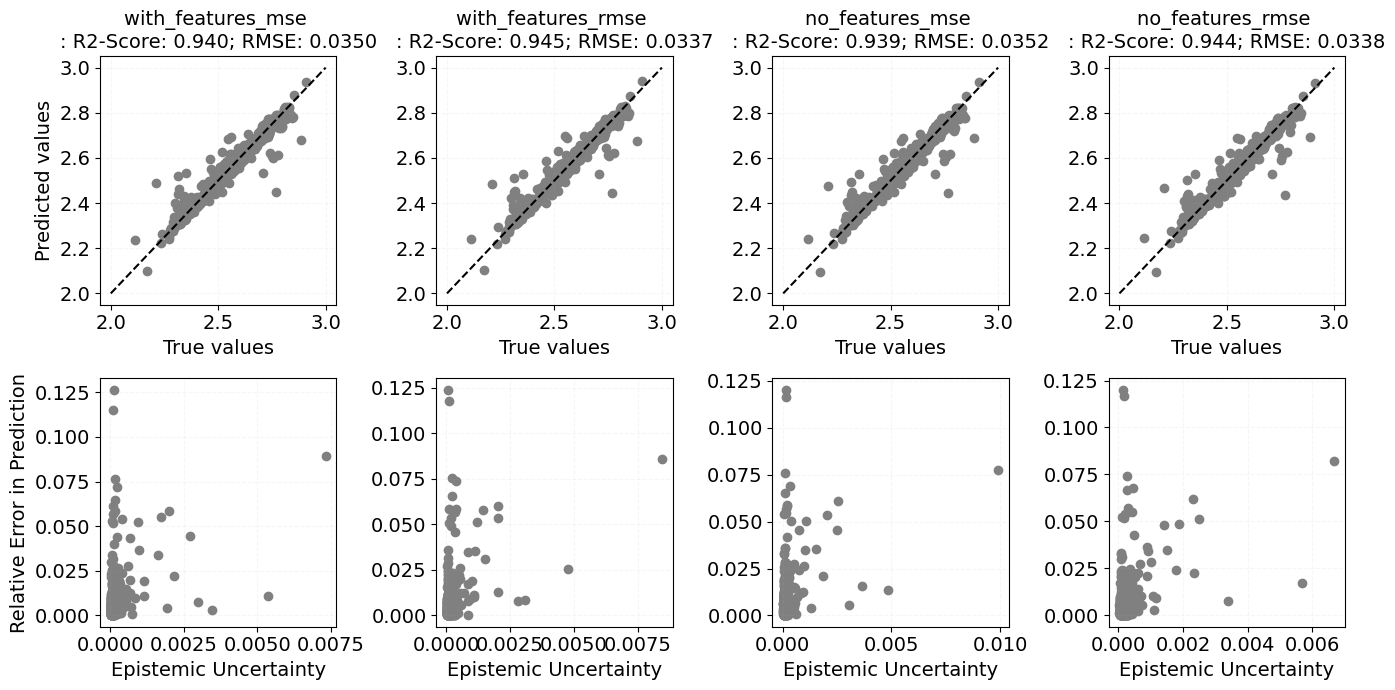

In [149]:
training_results = {}

# visualize true vs predicted values and their corresponding uncertainities
# Set figure size in inches (width, height)
fig, ax = plt.subplots(2, 4, figsize=(13.7, 7))  # 174mm x 78mm
for i, name in enumerate(
    [
    'with_features_mse',
    'with_features_rmse',
    'no_features_mse',
    'no_features_rmse'
    ]
): 
    mean_pred = np.array(mean_pred_dict[name].mean(axis=0))
    epistemic_unc = np.array(epistemic_unc_dict[name]).reshape(-1, 1)
    rel_error_train = np.abs(train_ys - mean_pred) / train_ys
    outlier_threshold = np.mean(epistemic_unc) + 3*np.std(epistemic_unc)
    metrics_dict = get_performance_metrics(
        y_true=train_ys,
        y_pred=mean_pred
    )
    training_results[name] = {
        'rmse': metrics_dict['rmse'],
        'r2_score': metrics_dict['r2_score'],
        'mean_epistemic_uncertainty': np.mean(epistemic_unc),
    }
    # plot true vs. predicted values
    ax[0][i].scatter(
        train_ys,
        mean_pred,
        color='gray'
    )
    ax[0][i].plot(
        [2, 3], [2, 3], color='black', linestyle='--'
    )
    # Set axis label and tick font sizes to 14 points
    ax[0][i].tick_params(axis='both', which='major', labelsize=14)
    ax[0][i].set_xlabel('True values', fontsize=14)
    if i == 0:
        ax[0][i].set_ylabel('Predicted values', fontsize=14)
    ax[0][i].grid(True, linestyle='--', alpha=0.1)
    ax[0][i].set_title(
        "{0} \n: R2-Score: {1:.3f}; RMSE: {2:.4f}".format(
            name,
            training_results[name]['r2_score'],
            training_results[name]['rmse']
        ),
        fontsize=14
    )
    # plot distribution of epistemic uncertainties
    ax[1][i].scatter(
        epistemic_unc,
        rel_error_train,
        color='gray'
    )
    ax[1][i].set_xlabel('Epistemic Uncertainty', fontsize=14)
    if i == 0:
        ax[1][i].set_ylabel('Relative Error in Prediction', fontsize=14)
    ax[1][i].tick_params(axis='both', which='major', labelsize=14)
    ax[1][i].grid(True, linestyle='--', alpha=0.1)
#plt.suptitle("Training data: True vs Predicted Values and Epistemic Uncertainties", fontsize=12)
plt.tight_layout()
# Save as EPS
plt.savefig(figs_dir / 'Chemprop_all_true_vs_predicted_and_uncertainties_training.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()

In [44]:
training_results

{'with_features_mse': {'rmse': 0.034987175999658886,
  'r2_score': 0.9401187584484821,
  'mean_epistemic_uncertainty': 0.00015970919},
 'with_features_rmse': {'rmse': 0.03367242619629064,
  'r2_score': 0.9445346399855445,
  'mean_epistemic_uncertainty': 0.00019082373},
 'no_features_mse': {'rmse': 0.035210001408089206,
  'r2_score': 0.9393535894289494,
  'mean_epistemic_uncertainty': 0.00017666336},
 'no_features_rmse': {'rmse': 0.03376569114301036,
  'r2_score': 0.9442269616617038,
  'mean_epistemic_uncertainty': 0.00021327058}}

### Test dataset

In [45]:
mean_pred_dict_testing = {}
epistemic_unc_dict_testing = {}
for name, ensemble, features in [
    ('with_features_mse', ensemble_with_features_mse, test_V_fs),
    ('with_features_rmse', ensemble_with_features_rmse, test_V_fs),
    ('no_features_mse', ensemble_no_features_mse, None),
    ('no_features_rmse', ensemble_no_features_rmse, None)
 ]:
    mean_pred, epistemic_unc = ensemble_predict(
        ensemble=ensemble,
        test_smis=test_smis,
        test_V_fs=features,
    )
    mean_pred_dict_testing[name] = mean_pred
    epistemic_unc_dict_testing[name] = epistemic_unc

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LO

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


with_features_mse
R2-score:: 0.778
Root Mean Squared Error: 0.0654
with_features_rmse
R2-score:: 0.784
Root Mean Squared Error: 0.0645
no_features_mse
R2-score:: 0.773
Root Mean Squared Error: 0.0662
no_features_rmse
R2-score:: 0.782
Root Mean Squared Error: 0.0649


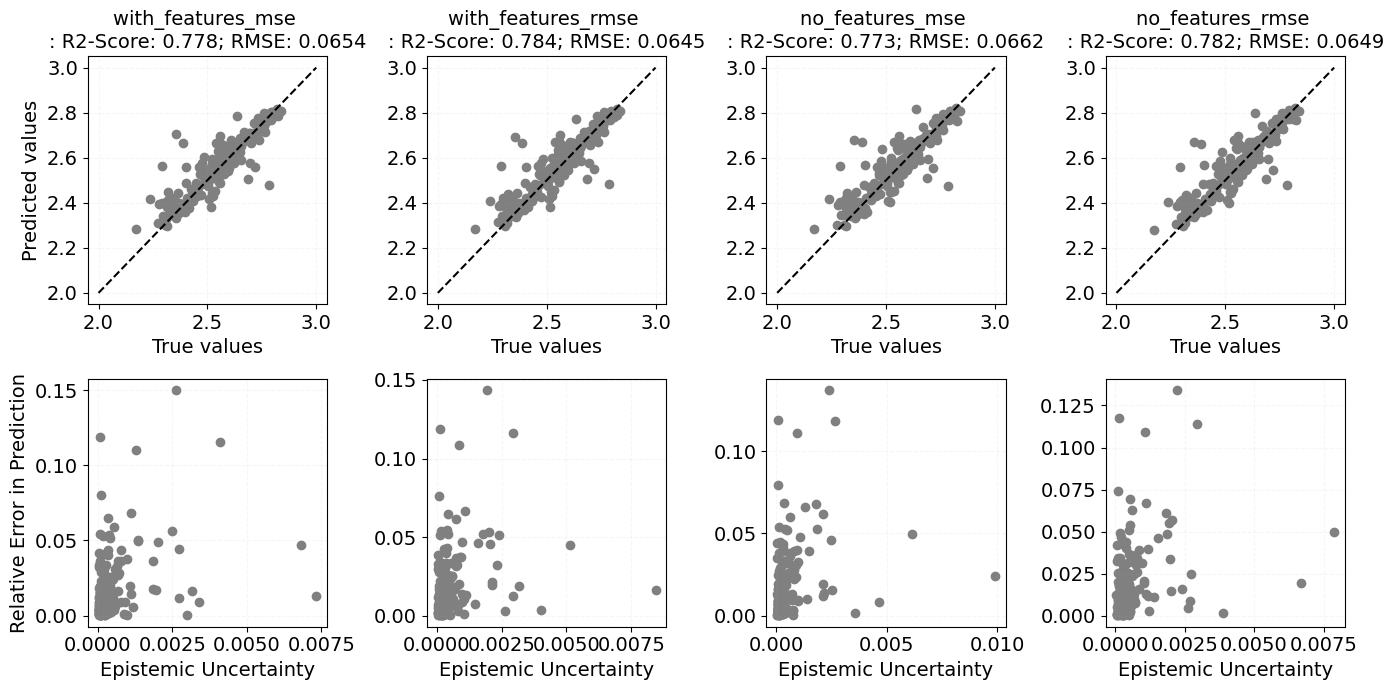

In [152]:
testing_results = {}
# visualize true vs predicted values and their corresponding uncertainities
# Set figure size in inches (width, height)
fig, ax = plt.subplots(2, 4, figsize=(13.7, 7))  # 174mm x 78mm
for i, name in enumerate(
    [
    'with_features_mse',
    'with_features_rmse',
    'no_features_mse',
    'no_features_rmse'
    ]
): 
    print(name)
    mean_pred = np.array(mean_pred_dict_testing[name].mean(axis=0))
    epistemic_unc = np.array(epistemic_unc_dict_testing[name]).reshape(-1, 1)
    rel_error_test = np.abs(df_smiles_test.loc[:, target_column].values - mean_pred) / df_smiles_test.loc[:, target_column].values
    outlier_threshold = np.mean(epistemic_unc) + 3*np.std(epistemic_unc)
    metrics_dict = get_performance_metrics(
        y_true=df_smiles_test.loc[:, target_column].values,
        y_pred=mean_pred
    )
    testing_results[name] = {
        'rmse': metrics_dict['rmse'],
        'r2_score': metrics_dict['r2_score'],
        'mean_epistemic_uncertainty': np.mean(epistemic_unc),
    }
    # plot true vs. predicted values
    ax[0][i].scatter(
        df_smiles_test.loc[:, target_column].values,
        mean_pred,
        color='gray'
    )
    ax[0][i].plot(
        [2, 3], [2, 3], color='black', linestyle='--'
    )
    # Set axis label and tick font sizes to 14 points
    ax[0][i].tick_params(axis='both', which='major', labelsize=14)
    ax[0][i].set_xlabel('True values', fontsize=14)
    if i == 0:
        ax[0][i].set_ylabel('Predicted values', fontsize=14)
    ax[0][i].grid(True, linestyle='--', alpha=0.1)
    ax[0][i].set_title(
        "{0} \n: R2-Score: {1:.3f}; RMSE: {2:.4f}".format(
            name,
            testing_results[name]['r2_score'],
            testing_results[name]['rmse']
        ),
        fontsize=14
    )
    # plot distribution of epistemic uncertainties
    ax[1][i].scatter(
        epistemic_unc,
        rel_error_test,
        color='gray'
    )
    ax[1][i].set_xlabel('Epistemic Uncertainty', fontsize=14)
    if i == 0:
        ax[1][i].set_ylabel('Relative Error in Prediction', fontsize=14)
    ax[1][i].tick_params(axis='both', which='major', labelsize=14)
    ax[1][i].grid(True, linestyle='--', alpha=0.1)
#plt.suptitle("Testing data: True vs Predicted Values and Epistemic Uncertainties", fontsize=12)
plt.tight_layout()
# Save as EPS
plt.savefig(
    figs_dir / 'Chemprop_all_true_vs_predicted_and_uncertainties_testing.eps',
    format='eps',
    bbox_inches='tight'
)
plt.show()
plt.close()

### Best Model

R2-score:: 0.944
Root Mean Squared Error: 0.0338
R2-score:: 0.782
Root Mean Squared Error: 0.0649
Mean + 3*Std. dev. (training): 0.0014569819177268073
Mean + 3*Std. dev. (testing): 0.003113438608124852
Mean + 3*Std. dev. (training): 0.0014
Mean + 3*Std. dev. (testing): 0.0031


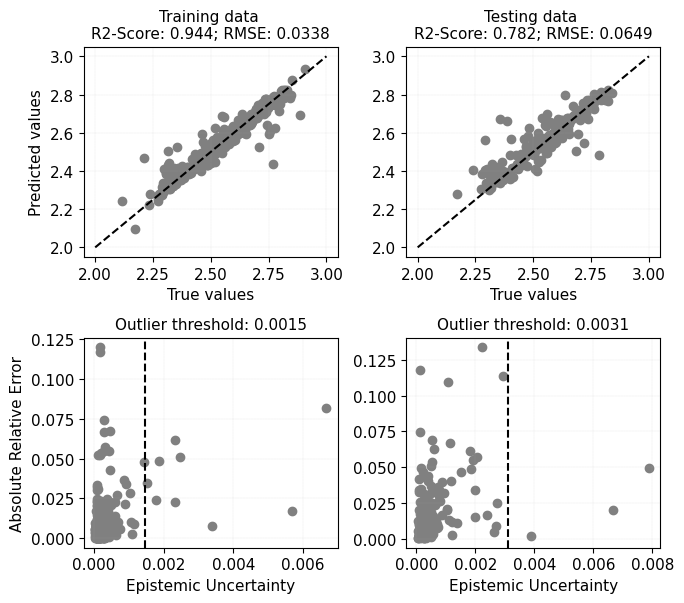

In [47]:
name_ = "no_features_rmse"
# visualize true vs predicted values and their corresponding uncertainities
# Set figure size in inches (width, height)
fig, ax = plt.subplots(2, 2, figsize=(6.85, 6.14))  # 174mm x 78mm
mean_pred_train = np.array(
    mean_pred_dict[name_].mean(axis=0)
)
epistemic_unc_train = np.array(epistemic_unc_dict[name_]).reshape(-1, 1)
metrics_dict_train = get_performance_metrics(
    y_true=train_ys,
    y_pred=mean_pred_train
)


mean_pred_test = np.array(
    mean_pred_dict_testing[name_].mean(axis=0)
)
epistemic_unc_test = np.array(epistemic_unc_dict_testing[name_]).reshape(-1, 1)

metrics_dict_test = get_performance_metrics(
    y_true=df_smiles_test.loc[:, target_column].values,
    y_pred=mean_pred_test
)

# will be slightly more conservative
outlier_threshold_train = np.mean(epistemic_unc_train) + 3*np.std(epistemic_unc_train)
outlier_threshold_test = np.mean(epistemic_unc_test) + 3*np.std(epistemic_unc_test)

print("Mean + 3*Std. dev. (training):", outlier_threshold_train)
print("Mean + 3*Std. dev. (testing):", outlier_threshold_test)

print("Mean + 3*Std. dev. (training): {0:.4f}".format(int(outlier_threshold_train*10000)/10000))
print("Mean + 3*Std. dev. (testing): {0:.4f}".format(int(outlier_threshold_test*10000)/10000))

rel_error_train = np.abs(train_ys - mean_pred_train) / train_ys
rel_error_test = np.abs(df_smiles_test.loc[:, target_column].values - mean_pred_test) / df_smiles_test.loc[:, target_column].values

# plot true vs. predicted values
ax[0][0].scatter(
    train_ys,
    mean_pred_train,
    color='gray'
)
ax[0][0].plot(
    [2, 3], [2, 3], color='black', linestyle='--'
)
ax[0][0].tick_params(axis='both', which='major', labelsize=11)
ax[0][0].set_xlabel('True values', fontsize=11)
ax[0][0].set_ylabel('Predicted values', fontsize=11)
ax[0][0].grid(True, linestyle='--', linewidth=0.1)
ax[0][0].set_title(
    "Training data \nR2-Score: {0:.3f}; RMSE: {1:.4f}".format(
        training_results[name_]['r2_score'],
        training_results[name_]['rmse']
    ),
    fontsize=11
)

ax[0][1].scatter(
    df_smiles_test.loc[:, target_column].values,
    mean_pred_test,
    color='gray'
)
ax[0][1].plot(
    [2, 3], [2, 3], color='black', linestyle='--'
)
# Set axis label and tick font sizes to 11 points
ax[0][1].tick_params(axis='both', which='major', labelsize=11)
ax[0][1].set_xlabel('True values', fontsize=11)
    
ax[0][1].grid(True, linestyle='--', linewidth=0.1)
ax[0][1].set_title(
    "Testing data \nR2-Score: {0:.3f}; RMSE: {1:.4f}".format(
        testing_results[name_]['r2_score'],
        testing_results[name_]['rmse']
    ),
    fontsize=11
)


# plot distribution of epistemic uncertainties
ax[1][0].scatter(
    epistemic_unc_train,
    rel_error_train,
    color='gray'
)
ax[1][0].axvline(outlier_threshold_train, color='black', linestyle='--')
ax[1][0].grid(True, linestyle='--', linewidth=0.1)
ax[1][0].set_xlabel('Epistemic Uncertainty', fontsize=11)
ax[1][0].set_ylabel('Absolute Relative Error', fontsize=11)
ax[1][0].tick_params(axis='both', which='major', labelsize=11)
ax[1][0].set_title(
    "Outlier threshold: {0:.4f}".format(
        outlier_threshold_train
    ),
    fontsize=11
)

ax[1][1].scatter(
    epistemic_unc_test,
    rel_error_test,
    color='gray'
)
ax[1][1].grid(True, linestyle='--', linewidth=0.1)
ax[1][1].set_xlabel('Epistemic Uncertainty', fontsize=11)
ax[1][1].tick_params(axis='both', which='major', labelsize=11)
ax[1][1].set_title(
    "Outlier threshold: {0:.4f}".format(
        outlier_threshold_test
    ),
    fontsize=11
)
ax[1][1].axvline(outlier_threshold_test, color='black', linestyle='--')
#plt.suptitle("Ensemble of D-MPNN models:True vs Predicted Values and Epistemic Uncertainties", fontsize=12)
plt.tight_layout()
plt.savefig(figs_dir / 'Chemprop_no_features_rmse_true_vs_predicted_and_uncertainties.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()

# 3. Ablation plot

In [48]:
# create a bar-chart comparing training and testing RMSE for different models and SVM as well
# load SVM metrics hjson
# # Save model results dictionary to HJSON file
import hjson

# read HJSON
with open(PROJECT_ROOT / 'data' / 'processed' / 'svm_models' / 'svm_model_results.hjson', 'r') as f:
    svm_metrics_hjson = hjson.load(f)

In [49]:
svm_metrics_hjson

OrderedDict([('Training_StandardScaling',
              OrderedDict([('r2_score', 0.9898202430699362),
                           ('rmse', 0.014425543862993122)])),
             ('Training_MinMaxScaling',
              OrderedDict([('r2_score', 0.8173543738301379),
                           ('rmse', 0.06110378738367292)])),
             ('Testing_MinMaxScaling',
              OrderedDict([('r2_score', 0.6587294038467015),
                           ('rmse', 0.08113862907453091)])),
             ('Testing_StandardScaling',
              OrderedDict([('r2_score', 0.7320528401813939),
                           ('rmse', 0.0718956822010479)]))])

In [50]:
training_results

{'with_features_mse': {'rmse': 0.034987175999658886,
  'r2_score': 0.9401187584484821,
  'mean_epistemic_uncertainty': 0.00015970919},
 'with_features_rmse': {'rmse': 0.03367242619629064,
  'r2_score': 0.9445346399855445,
  'mean_epistemic_uncertainty': 0.00019082373},
 'no_features_mse': {'rmse': 0.035210001408089206,
  'r2_score': 0.9393535894289494,
  'mean_epistemic_uncertainty': 0.00017666336},
 'no_features_rmse': {'rmse': 0.03376569114301036,
  'r2_score': 0.9442269616617038,
  'mean_epistemic_uncertainty': 0.00021327058}}

In [51]:
testing_results

{'with_features_mse': {'rmse': 0.06542911207755527,
  'r2_score': 0.7780855443995125,
  'mean_epistemic_uncertainty': 0.00044825877},
 'with_features_rmse': {'rmse': 0.06454714329349287,
  'r2_score': 0.7840279292513118,
  'mean_epistemic_uncertainty': 0.0004873954},
 'no_features_mse': {'rmse': 0.06619273329253633,
  'r2_score': 0.7728754031077467,
  'mean_epistemic_uncertainty': 0.00046954342},
 'no_features_rmse': {'rmse': 0.06487491181480232,
  'r2_score': 0.7818289604199651,
  'mean_epistemic_uncertainty': 0.0005118256}}

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


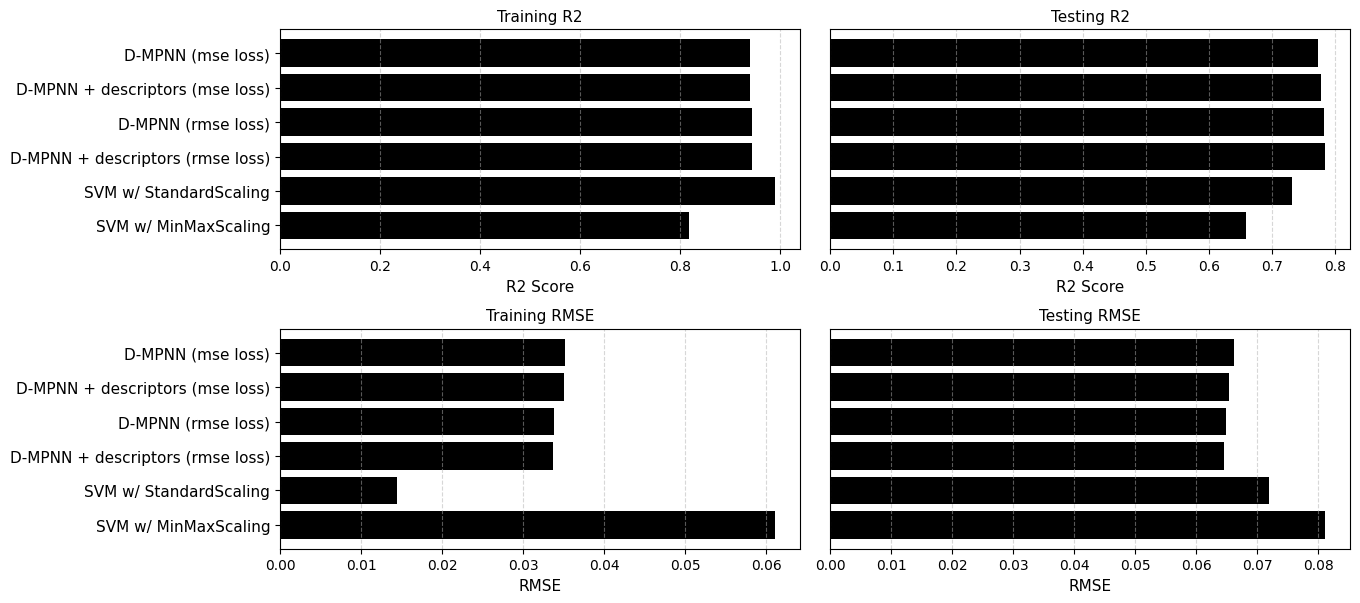

In [52]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(13.7, 6.14))
model_labels = [
    'SVM w/ MinMaxScaling',
    'SVM w/ StandardScaling',
    'D-MPNN + descriptors (rmse loss)',
    'D-MPNN (rmse loss)',
    'D-MPNN + descriptors (mse loss)',
    'D-MPNN (mse loss)'
]
y_pos = [1, 2, 3, 4, 5, 6]

# Training R2
ax[0, 0].barh(y_pos, [
    svm_metrics_hjson['Training_MinMaxScaling']['r2_score'],
    svm_metrics_hjson['Training_StandardScaling']['r2_score'],
    training_results['with_features_rmse']['r2_score'],
    training_results['no_features_rmse']['r2_score'],
    training_results['with_features_mse']['r2_score'],
    training_results['no_features_mse']['r2_score'],
],
color='black'
)
ax[0, 0].set_yticks(y_pos, model_labels, fontsize=11)
ax[0, 0].set_xlabel('R2 Score', fontsize=11)
ax[0, 0].set_title('Training R2', fontsize=11)
ax[0, 0].grid(axis='x', linestyle='--', alpha=0.5)

# Testing R2
ax[0, 1].barh(y_pos, [
    svm_metrics_hjson['Testing_MinMaxScaling']['r2_score'],
    svm_metrics_hjson['Testing_StandardScaling']['r2_score'],
    testing_results['with_features_rmse']['r2_score'],
    testing_results['no_features_rmse']['r2_score'],
    testing_results['with_features_mse']['r2_score'],
    testing_results['no_features_mse']['r2_score'],
], color='black')
ax[0, 1].set_xlabel('R2 Score', fontsize=11)
ax[0, 1].set_title('Testing R2', fontsize=11)
ax[0, 1].set_yticks([])  # Only show y-ticks on left
ax[0, 1].grid(axis='x', linestyle='--', alpha=0.5)

# Training RMSE
ax[1, 0].barh(y_pos, [
    svm_metrics_hjson['Training_MinMaxScaling']['rmse'],
    svm_metrics_hjson['Training_StandardScaling']['rmse'],
    training_results['with_features_rmse']['rmse'],
    training_results['no_features_rmse']['rmse'],
    training_results['with_features_mse']['rmse'],
    training_results['no_features_mse']['rmse'],
], color='black')
ax[1, 0].set_yticks(y_pos, model_labels, fontsize=11)
ax[1, 0].set_xlabel('RMSE', fontsize=11)
ax[1, 0].set_title('Training RMSE', fontsize=11)
ax[1, 0].grid(axis='x', linestyle='--', alpha=0.5)

# Testing RMSE
ax[1, 1].barh(y_pos, [
    svm_metrics_hjson['Testing_MinMaxScaling']['rmse'],
    svm_metrics_hjson['Testing_StandardScaling']['rmse'],
    testing_results['with_features_rmse']['rmse'],
    testing_results['no_features_rmse']['rmse'],
    testing_results['with_features_mse']['rmse'],
    testing_results['no_features_mse']['rmse'],
], color='black')
ax[1, 1].set_xlabel('RMSE', fontsize=11)
ax[1, 1].set_title('Testing RMSE', fontsize=11)
ax[1, 1].set_yticks([])
ax[1, 1].grid(axis='x', linestyle='--', alpha=0.5)

#plt.suptitle('Performance Metrics for Training and Testing Sets', fontsize=12)
plt.tight_layout()
plt.savefig(figs_dir / 'performance_metrics_ablation_barplots.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()

# 4. Applicability Domain Analysis

This section evaluates the reliability of model predictions using multiple applicability domain (AD) methods:
- **Leverage**
- **Mahalanobis distance**
- **kNN distance**
- **PCA T² statistic**

AD analysis helps identify test samples where predictions may be unreliable due to being outside the domain of the training data. Visualizations and summary statistics are provided for each method.


- Multiple AD methods (Leverage, Mahalanobis, kNN, PCA T²) are used for robust assessment.
- Samples flagged by multiple methods are high-risk predictions.
- Consider collecting more training data in regions with high prediction errors.
- Apply AD filtering in production to flag uncertain predictions.

Consensus outliers (flagged by ≥2 methods) are reported above. Use these to guide further data collection and model improvement.

In [53]:
def prep_data_loader(
    smis_,
    V_fs=None,
    num_workers=20,
    shuffle=False
):
    """
    Prepare a data loader for the given SMILES strings and optional features.
    Parameters:
        smis_ (list of str): List of SMILES strings representing molecules.
        V_fs (list, optional): Additional features for each molecule.
        num_workers (int, optional): Number of worker processes for data loading.
        shuffle (bool, optional): Whether to shuffle the data.
    Returns:
        DataLoader: A PyTorch DataLoader for the dataset.
    """
    # create list of molecule objects from SMILES strings
    mols_ = [
        utils.make_mol(smi, keep_h=False, add_h=False) for smi in smis_
    ]
    # if additional features are to be used
    if V_fs is not None:
        # create MoleculeDatapoint objects with additional features
        data_ = [
            data.MoleculeDatapoint(mol, x_d=X_d) for mol, X_d in zip(mols_, V_fs)
        ]
    else:
        # create MoleculeDatapoint objects without additional features
        data_ = [data.MoleculeDatapoint(mol) for mol in mols_]
    
    # initialize featurizer and dataset
    featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
    dset_ = data.MoleculeDataset(data_, featurizer)
    
    # create data loader
    return data.build_dataloader(
        dset_,
        batch_size=len(smis_),
        num_workers=num_workers,
        shuffle=shuffle
    )

In [54]:
train_data_loader = prep_data_loader(
    smis_=train_smis,
)

In [55]:
test_data_loader = prep_data_loader(
    smis_=test_smis,
)

In [56]:
import torch

def get_MPNN_encodings(
    model_ensemble_,
    data_loader_
):
    """
    """
    all_encodings_list = []
    for model_0 in model_ensemble_:
        with torch.no_grad():
            encodings = [
                model_0.encoding(batch.bmg, batch.V_d, batch.X_d, i=1)
                for batch in data_loader_
            ]
    encodings = torch.cat(encodings, 0)
    all_encodings_list.append(encodings)

    all_encodings_tensor = torch.stack(all_encodings_list, dim=0)
    return all_encodings_tensor

In [57]:
train_data_encodings = get_MPNN_encodings(
    model_ensemble_=ensemble_no_features_rmse,
    data_loader_=train_data_loader
)
train_data_encodings.shape

torch.Size([1, 683, 300])

In [58]:
h_train_mean = train_data_encodings.mean(dim=0)
h_train_mean.shape

torch.Size([683, 300])

In [59]:
test_data_encodings = get_MPNN_encodings(
    model_ensemble_=ensemble_no_features_rmse,
    data_loader_=test_data_loader
)

In [60]:
h_test_mean = test_data_encodings.mean(dim=0)
h_test_mean.shape

torch.Size([219, 300])

In [61]:
# normalization
from sklearn.preprocessing import StandardScaler

# If mean_encodings is a torch tensor, convert to numpy
h_train_mean_np = h_train_mean.cpu().numpy()  # shape: (683, 300)

scaler = StandardScaler()
h_train_mean_scaled = scaler.fit_transform(h_train_mean_np)

In [62]:
# If mean_encodings is a torch tensor, convert to numpy
h_test_mean_np = h_test_mean.cpu().numpy()  # shape: (683, 300)

h_test_mean_scaled = scaler.transform(h_test_mean_np)

In [63]:
h_test_mean_np.shape

(219, 300)

In [64]:
import scipy.linalg

In [65]:
# add code for leverage values
def calculate_leverage_values(
    X_train,
    X_test,
    reg_param = 1e-4  
):
    """
    Calculate leverage values for test samples based on training data.
    """    
    # Add a column of ones to X_train for the intercept
    X_train_augmented = np.hstack([np.ones((X_train.shape[0], 1)), X_train])

    # Calculate the hat matrix
    XtX = X_train_augmented.T @ X_train_augmented + reg_param * np.eye(X_train_augmented.shape[1])
    hat_matrix = X_train_augmented @ np.linalg.inv(XtX) @ X_train_augmented.T

    # Calculate leverage values for training data (diagonal of hat matrix)
    leverage_train = np.diag(hat_matrix)

    # Add a column of ones to X_test for the intercept
    X_test_augmented = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

    # Calculate leverage values for test data
    leverage_test = np.sum(X_test_augmented @ np.linalg.inv(XtX) * X_test_augmented, axis=1)

    return leverage_train, leverage_test

In [66]:
leverage_train, leverage_test = calculate_leverage_values(
    X_train=h_train_mean_scaled,
    X_test=h_test_mean_scaled
)

In [67]:
leverage_test.max()

238.89762085762257

In [68]:
leverage_train.max()

0.9999486630020237

In [69]:
# find outliers based on leverage values
leverage_threshold = 3 *(300+1)/len(leverage_train)

print("Leverage threshold: {:.3f}".format(leverage_threshold))

outliers = np.where(leverage_test > leverage_threshold)[0]
within_leverage_threshold = np.where(leverage_test <= leverage_threshold)[0]
print('Testing data')
print("Number of outliers: ", len(outliers))
print("Number within leverage threshold: ", len(within_leverage_threshold))

Leverage threshold: 1.322
Testing data
Number of outliers:  59
Number within leverage threshold:  160


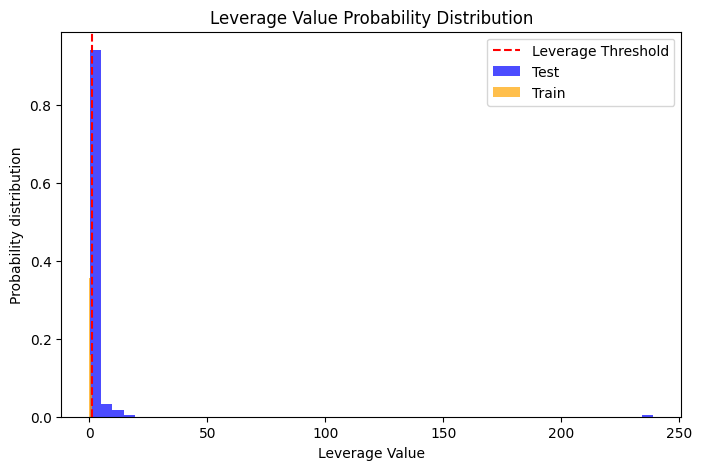

In [70]:
## Compute histogram counts
counts_train, bins_train = np.histogram(leverage_train, bins=5)
counts_test, bins_test = np.histogram(leverage_test, bins=50)

# Normalize so max height is 1
probs_train = counts_train / counts_train.sum()
probs_test = counts_test / counts_test.sum()

plt.figure(figsize=(8, 5))
plt.bar(bins_test[:-1], probs_test, width=np.diff(bins_test), alpha=0.7, label='Test', align='edge', color='blue')
plt.bar(bins_train[:-1], probs_train, width=np.diff(bins_train), alpha=0.7, label='Train', align='edge', color='orange')
plt.axvline(leverage_threshold, color='red', linestyle='--', label='Leverage Threshold')
plt.xlabel('Leverage Value')
plt.ylabel('Probability distribution')
plt.title('Leverage Value Probability Distribution')
plt.legend()
plt.show()

In [71]:
np.sum(leverage_test > 200)

1

In [72]:
def calculate_mahalanobis_ad(
    X_train,
    X_test,
    reg_param = 1e-4
):
    """Calculate Mahalanobis distance with robust covariance estimation"""
    mean_vec = np.mean(X_train, axis=0)
    cov_matrix = np.cov(X_train, rowvar=False)
    cov_matrix += reg_param * np.eye(cov_matrix.shape[0])
    try:
        inv_cov_matrix = np.linalg.inv(cov_matrix)
        mahal_train = [mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_train]
        mahal_test = [mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_test]
        return np.array(mahal_train), np.array(mahal_test)
    except np.linalg.LinAlgError:
        print("Warning: Singular covariance matrix in Mahalanobis calculation")
        return None, None

In [73]:
mahal_train, mahal_test = calculate_mahalanobis_ad(h_train_mean_scaled, h_test_mean_scaled)
mahal_threshold = np.percentile(mahal_train, 95) if mahal_train is not None else None
if mahal_train is not None:
    print(f"Mahalanobis threshold: {mahal_threshold}")
    print(f"Test samples outside AD (Mahalanobis): {np.sum(mahal_test > mahal_threshold)}/{len(mahal_test)}")

Mahalanobis threshold: 22.888767993743933
Test samples outside AD (Mahalanobis): 65/219


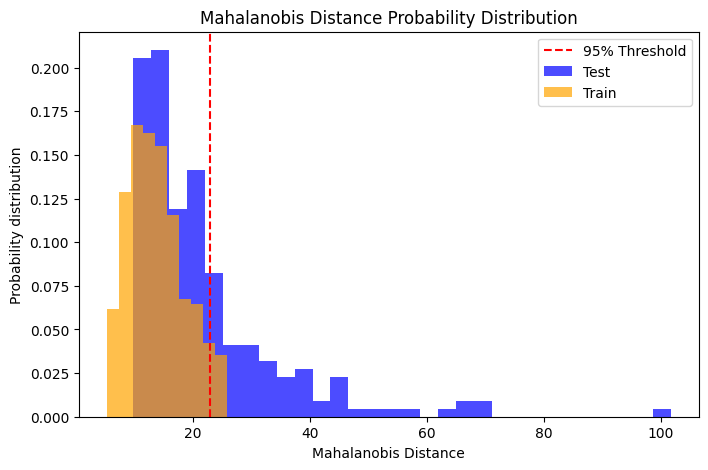

In [74]:
# Compute histogram counts for train and test
counts_train, bins_train = np.histogram(mahal_train, bins=10)
counts_test, bins_test = np.histogram(mahal_test, bins=30)

# Normalize so the sum of heights is 1 (probability distribution)
probs_train = counts_train / counts_train.sum()
probs_test = counts_test / counts_test.sum()

plt.figure(figsize=(8, 5))
plt.bar(bins_test[:-1], probs_test, width=np.diff(bins_test), alpha=0.7, label='Test', align='edge', color='blue')
plt.bar(bins_train[:-1], probs_train, width=np.diff(bins_train), alpha=0.7, label='Train', align='edge', color='orange')
plt.axvline(mahal_threshold, color='red', linestyle='--', label='95% Threshold')
plt.xlabel('Mahalanobis Distance')
plt.ylabel('Probability distribution')
plt.title('Mahalanobis Distance Probability Distribution')
plt.legend()
plt.show()

In [75]:
def calculate_knn_ad(X_train, X_test, k_values=[3, 5, 10]):
    """Calculate kNN distances with multiple k values"""
    knn_results = {}
    for k in k_values:
        if k < len(X_train):
            knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
            knn.fit(X_train)
            train_distances, _ = knn.kneighbors(X_train)
            train_mean_dist = train_distances[:, 1:].mean(axis=1)
            test_distances, _ = knn.kneighbors(X_test)
            test_mean_dist = test_distances.mean(axis=1)
            knn_results[k] = {
                'train_distances': train_mean_dist,
                'test_distances': test_mean_dist,
                'threshold': np.percentile(train_mean_dist, 95)
            }
    return knn_results

In [76]:
# Replace X_train_scaled, X_test_scaled, y_train, y_test with your actual variables
knn_results = calculate_knn_ad(h_train_mean_scaled, h_test_mean_scaled)
print("\nkNN Applicability Domain Results:")
for k, results in knn_results.items():
    threshold = results['threshold']
    outside_ad = np.sum(results['test_distances'] > threshold)
    print(f"k={k}: threshold={threshold:.4f}, outside AD: {outside_ad}/{len(results['test_distances'])}")


kNN Applicability Domain Results:
k=3: threshold=14.8760, outside AD: 13/219
k=5: threshold=16.3946, outside AD: 12/219
k=10: threshold=18.3286, outside AD: 11/219


In [77]:
knn_results.keys()

dict_keys([3, 5, 10])

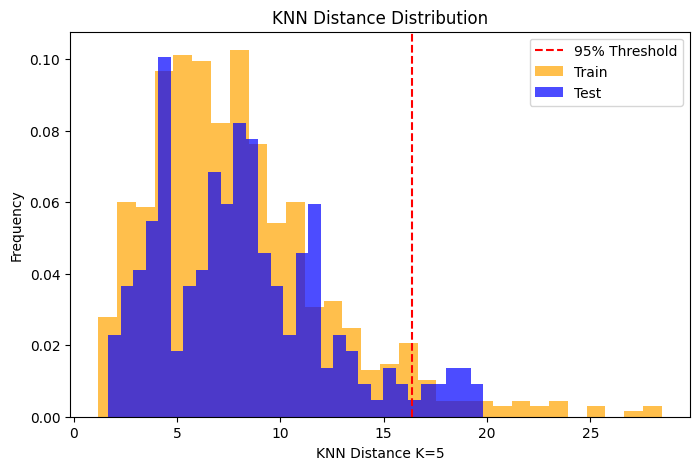

In [78]:
# Compute histogram counts for train and test
counts_train, bins_train = np.histogram(knn_results[5]['train_distances'], bins=30)
counts_test, bins_test = np.histogram(knn_results[5]['test_distances'], bins=30)

# Normalize so the sum of heights is 1 (probability distribution)
probs_train = counts_train / counts_train.sum()
probs_test = counts_test / counts_test.sum()

# visualize mahalanobis AD results
plt.figure(figsize=(8, 5))
plt.bar(bins_train[:-1], probs_train, width=np.diff(bins_train), alpha=0.7, label='Train', align='edge', color='orange')
plt.bar(bins_test[:-1], probs_test, width=np.diff(bins_test), alpha=0.7, label='Test', align='edge', color='blue')
plt.axvline(knn_results[5]['threshold'], color='red', linestyle='--', label='95% Threshold')
plt.xlabel('KNN Distance K=5')
plt.ylabel('Frequency')
plt.title('KNN Distance Distribution')
plt.legend()
plt.show()

In [220]:
def calculate_pca_ad(X_train, X_test, n_components=10, variance_threshold=0.95):
    """Calculate PCA-based applicability domain"""
    pca = PCA(n_components=n_components)
    pca.fit(X_train)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.argmax(cumvar >= variance_threshold) + 1
    pca_reduced = PCA(n_components=n_components)
    X_train_pca = pca_reduced.fit_transform(X_train)
    X_test_pca = pca_reduced.transform(X_test)
    mean_pca = np.mean(X_train_pca, axis=0)
    cov_pca = np.cov(X_train_pca, rowvar=False)
    if n_components == 1:
        inv_cov_pca = 1.0 / cov_pca
        t2_train = [(x - mean_pca)**2 * inv_cov_pca for x in X_train_pca.flatten()]
        t2_test = [(x - mean_pca)**2 * inv_cov_pca for x in X_test_pca.flatten()]
    else:
        inv_cov_pca = np.linalg.inv(cov_pca + 1e-6 * np.eye(cov_pca.shape[0]))
        t2_train = [mahalanobis(x, mean_pca, inv_cov_pca)**2 for x in X_train_pca]
        t2_test = [mahalanobis(x, mean_pca, inv_cov_pca)**2 for x in X_test_pca]
    return X_train_pca, X_test_pca, np.array(t2_train), np.array(t2_test), pca_reduced

In [221]:
# --- Calculate AD metrics ---
X_train_pca, X_test_pca, t2_train, t2_test, pca_model = calculate_pca_ad(h_train_mean_scaled, h_test_mean_scaled)
t2_threshold = np.percentile(t2_train, 95)
print(f"T² threshold: {t2_threshold}")
print(f"Test samples outside AD (T²): {np.sum(t2_test > t2_threshold)}/{len(t2_test)}")

T² threshold: 2.5438919782638547
Test samples outside AD (T²): 12/219


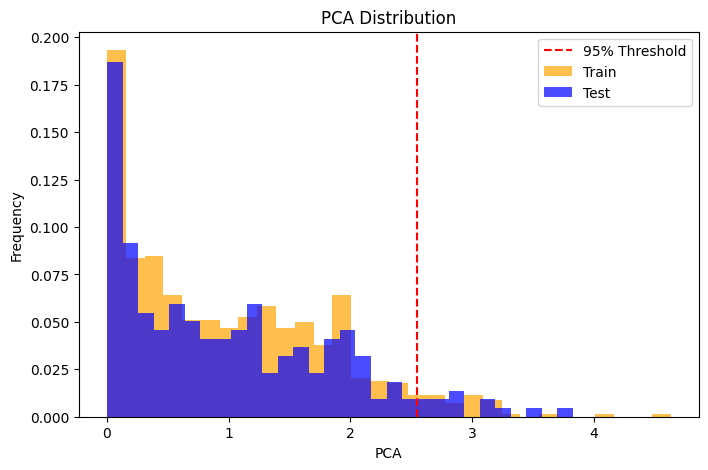

In [222]:
# Compute histogram counts for train and test
counts_train, bins_train = np.histogram(t2_train, bins=30)
counts_test, bins_test = np.histogram(t2_test, bins=30)

# Normalize so the sum of heights is 1 (probability distribution)
probs_train = counts_train / counts_train.sum()
probs_test = counts_test / counts_test.sum()

# visualize mahalanobis AD results
plt.figure(figsize=(8, 5))
plt.bar(bins_train[:-1], probs_train, width=np.diff(bins_train), alpha=0.7, label='Train', align='edge', color='orange')
plt.bar(bins_test[:-1], probs_test, width=np.diff(bins_test), alpha=0.7, label='Test', align='edge', color='blue')
plt.axvline(t2_threshold, color='red', linestyle='--', label='95% Threshold')
plt.xlabel('PCA')
plt.ylabel('Frequency')
plt.title('PCA Distribution')
plt.legend()
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


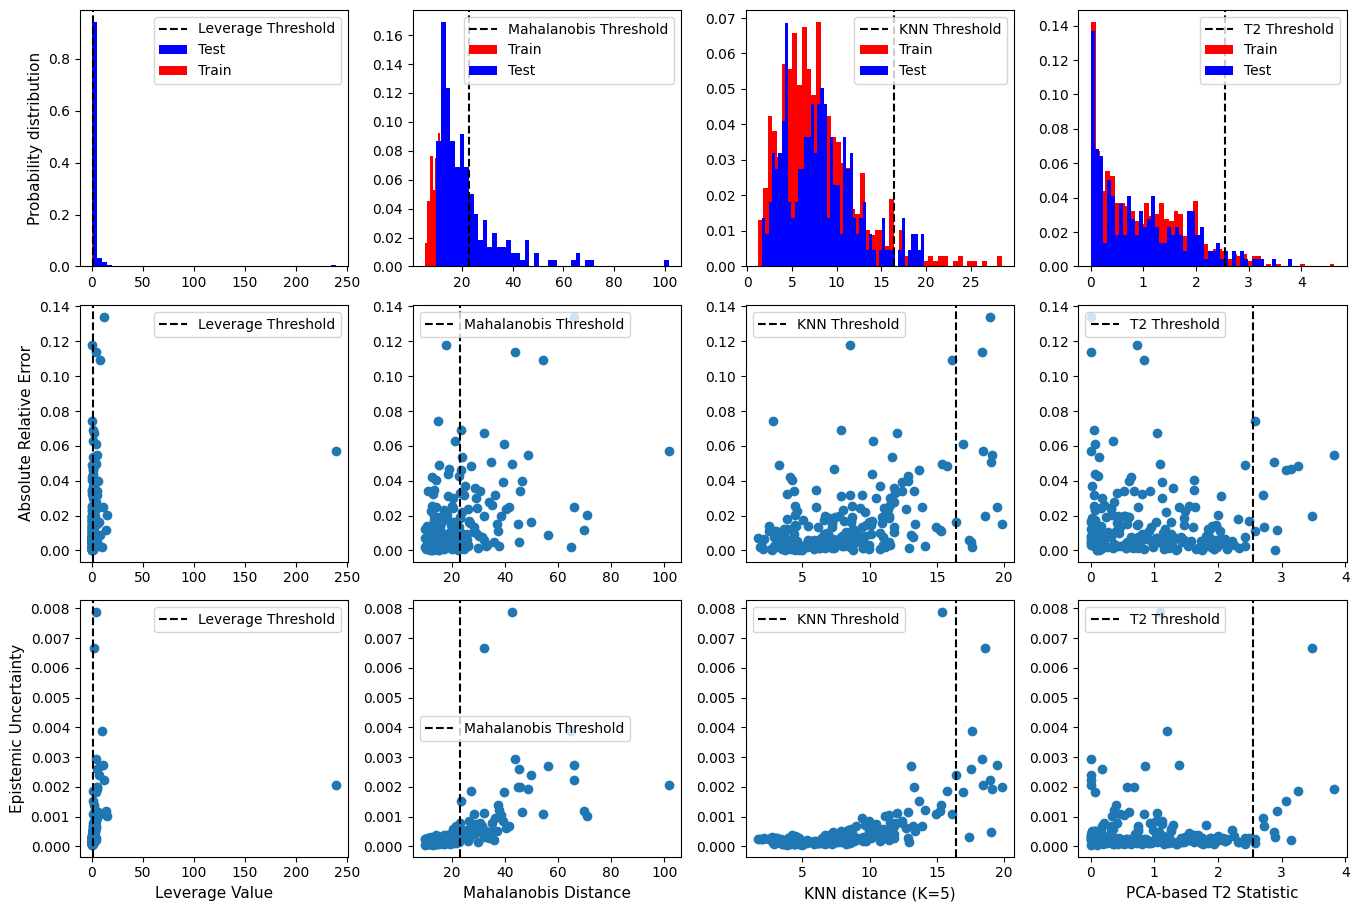

In [223]:
fig, ax = plt.subplots(3, 4, figsize=(13.7, 9.21))  # 174mm x 78mm
## Compute histogram counts
counts_train, bins_train = np.histogram(leverage_train, bins=5)
counts_test, bins_test = np.histogram(leverage_test, bins=50)

# Normalize so max height is 1
probs_train = counts_train / counts_train.sum()
probs_test = counts_test / counts_test.sum()
ax[0][0].bar(bins_test[:-1], probs_test, width=np.diff(bins_test), label='Test', align='edge', color='blue')
ax[0][0].bar(bins_train[:-1], probs_train, width=np.diff(bins_train), label='Train', align='edge', color='red')
ax[0][0].axvline(leverage_threshold, color='black', linestyle='--', label='Leverage Threshold')
ax[0][0].set_ylabel('Probability distribution',fontsize=11)
ax[0][0].legend(fontsize=10)

## Compute histogram counts
counts_train, bins_train = np.histogram(mahal_train, bins=20)
counts_test, bins_test = np.histogram(mahal_test, bins=50)

# Normalize so max height is 1
probs_train = counts_train / counts_train.sum()
probs_test = counts_test / counts_test.sum()
ax[0][1].bar(bins_train[:-1], probs_train, width=np.diff(bins_train), label='Train', align='edge', color='red')
ax[0][1].bar(bins_test[:-1], probs_test, width=np.diff(bins_test), label='Test', align='edge', color='blue')
ax[0][1].axvline(mahal_threshold, color='black', linestyle='--', label='Mahalanobis Threshold')
ax[0][1].legend(fontsize=10)

# Compute histogram counts
counts_train, bins_train = np.histogram(knn_results[5]['train_distances'], bins=50)
counts_test, bins_test = np.histogram(knn_results[5]['test_distances'], bins=50)

# Normalize so max height is 1
probs_train = counts_train / counts_train.sum()
probs_test = counts_test / counts_test.sum()
ax[0][2].bar(bins_train[:-1], probs_train, width=np.diff(bins_train), label='Train', align='edge', color='red')
ax[0][2].bar(bins_test[:-1], probs_test, width=np.diff(bins_test), label='Test', align='edge', color='blue')
ax[0][2].axvline(knn_results[5]['threshold'], color='black', linestyle='--', label='KNN Threshold')
ax[0][2].legend(fontsize=10)

# Compute histogram counts
counts_train, bins_train = np.histogram(t2_train, bins=50)
counts_test, bins_test = np.histogram(t2_test, bins=50)

# Normalize so max height is 1
probs_train = counts_train / counts_train.sum()
probs_test = counts_test / counts_test.sum()
ax[0][3].bar(bins_train[:-1], probs_train, width=np.diff(bins_train), label='Train', align='edge', color='red')
ax[0][3].bar(bins_test[:-1], probs_test, width=np.diff(bins_test), label='Test', align='edge', color='blue')
ax[0][3].axvline(t2_threshold, color='black', linestyle='--', label='T2 Threshold')
ax[0][3].legend(fontsize=10)

ax[1][0].scatter(
    leverage_test,
    rel_error_test
)
ax[1][0].axvline(leverage_threshold, color='black', linestyle='--', label='Leverage Threshold')
ax[1][0].set_ylabel('Absolute Relative Error', fontsize=11)
ax[1][0].legend(loc='upper right')
ax[1][1].scatter(
    mahal_test,
    rel_error_test
)
ax[1][1].axvline(mahal_threshold, color='black', linestyle='--', label='Mahalanobis Threshold')
ax[1][1].legend(loc='upper left')
ax[1][2].scatter(
    knn_results[5]['test_distances'],
    rel_error_test
)
ax[1][2].axvline(knn_results[5]['threshold'], color='black', linestyle='--', label='KNN Threshold')
ax[1][2].legend(loc='upper left')
ax[1][3].scatter(
    t2_test,
    rel_error_test
)
ax[1][3].axvline(t2_threshold, color='black', linestyle='--', label='T2 Threshold')
ax[1][3].legend(loc='upper left')

ax[2][0].scatter(
    leverage_test,
    epistemic_unc_test
)
ax[2][0].axvline(leverage_threshold, color='black', linestyle='--', label='Leverage Threshold')
ax[2][0].set_xlabel('Leverage Value', fontsize=11)
ax[2][0].set_ylabel('Epistemic Uncertainty', fontsize=11)
ax[2][0].legend(loc='upper right')

ax[2][1].scatter(
    mahal_test,
    epistemic_unc_test
)
ax[2][1].axvline(mahal_threshold, color='black', linestyle='--', label='Mahalanobis Threshold')
ax[2][1].set_xlabel('Mahalanobis Distance', fontsize=11)
ax[2][1].legend(loc='center left')

ax[2][2].scatter(
    knn_results[5]['test_distances'],
    epistemic_unc_test
)
ax[2][2].axvline(knn_results[5]['threshold'], color='black', linestyle='--', label='KNN Threshold')
ax[2][2].set_xlabel('KNN distance (K=5)', fontsize=11)
ax[2][2].legend(loc='upper left')

ax[2][3].scatter(
    t2_test,
    epistemic_unc_test
)
ax[2][3].axvline(t2_threshold, color='black', linestyle='--', label='T2 Threshold')
ax[2][3].set_xlabel('PCA-based T2 Statistic', fontsize=11)
ax[2][3].legend(loc='upper left')
#plt.suptitle('Applicability Domain Analysis', fontsize=12)

plt.tight_layout()
plt.savefig(figs_dir / 'applicability_domain_analysis_plots.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()

# Fixed test data results

In [224]:
df_smiles_test[(leverage_test > 200)]

,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean,Moleculer Weight,Proxy for Free Volume,Rotatable Bonds,Aromatic Rings,Topological Polar Surface Area,H-Bond Donors,H-Bond Acceptors
117,454,CAO_080,2.4829,P,I,vinylchloroacetate,C=CC(C(=O)[O-])Cl,PubChemPy,C=CC(C(=O)[O-])Cl,vinylchloroacetate,C=CC(Cl)C(=O)[O-],119.527,16.998647,2,0,40.13,0,2


In [225]:
leverage_test[(leverage_test > 200)]

array([238.89762086])

In [226]:
mahal_test[(leverage_test > 200)]

array([101.63182083])

In [227]:
knn_results[5]['test_distances'][(leverage_test > 200)]

array([18.3925518])

In [228]:
t2_test[(leverage_test > 200)]

array([[0.00870343]], dtype=float32)

In [229]:
epistemic_unc_test[(leverage_test > 200)]

array([[0.00205892]], dtype=float32)

In [230]:
rel_error_test[(leverage_test > 200)]

array([[0.05724155]])

Notice the really high leverage value for vinylchloroacetate. On dispo I found it's SMILES notation is wrong, the correct one is C=COC(=O)CCl thus could be a typo in source table. Now reworking all results by fixing this.

In [231]:
test_smis[(leverage_test > 200)]

117    C=CC(Cl)C(=O)[O-]
Name: SMILES_clean, dtype: object

In [232]:
test_smis_fixed = test_smis.copy()

In [233]:
test_smis_fixed[(leverage_test > 200)] = 'C=COC(=O)CCl'  # corrected SMILES for the outlier molecule

In [234]:
test_V_fs[(leverage_test > 200)]

array([[119.527     ,  16.99864723,   2.        ,   0.        ,
         40.13      ,   0.        ,   2.        ]])

In [235]:
compute_descriptors(smiles='C=COC(=O)CCl')

{'Moleculer Weight': 120.535,
 'Proxy for Free Volume': 17.14254386857143,
 'Rotatable Bonds': 2,
 'Aromatic Rings': 0,
 'Topological Polar Surface Area': 26.3,
 'H-Bond Donors': 0,
 'H-Bond Acceptors': 2}

In [236]:
test_V_fs_fixed = test_V_fs.copy()
test_V_fs_fixed[(leverage_test > 200)] = np.array(
    [[120.535, 17.14254386857143, 2, 0, 26.3, 0, 2]]
) 

## Making prediction for all cases

In [237]:
mean_pred_dict_testing_fixed = {}
epistemic_unc_dict_testing_fixed = {}
for name, ensemble, features in [
    ('with_features_mse', ensemble_with_features_mse, test_V_fs_fixed),
    ('with_features_rmse', ensemble_with_features_rmse, test_V_fs_fixed),
    ('no_features_mse', ensemble_no_features_mse, None),
    ('no_features_rmse', ensemble_no_features_rmse, None)
 ]:
    mean_pred, epistemic_unc = ensemble_predict(
        ensemble=ensemble,
        test_smis=test_smis_fixed,
        test_V_fs=features,
    )
    mean_pred_dict_testing_fixed[name] = mean_pred
    epistemic_unc_dict_testing_fixed[name] = epistemic_unc

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVIC

with_features_mse
R2-score:: 0.782
Root Mean Squared Error: 0.0649
with_features_rmse
R2-score:: 0.787
Root Mean Squared Error: 0.0641
no_features_mse
R2-score:: 0.779
Root Mean Squared Error: 0.0654
no_features_rmse
R2-score:: 0.786
Root Mean Squared Error: 0.0642


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


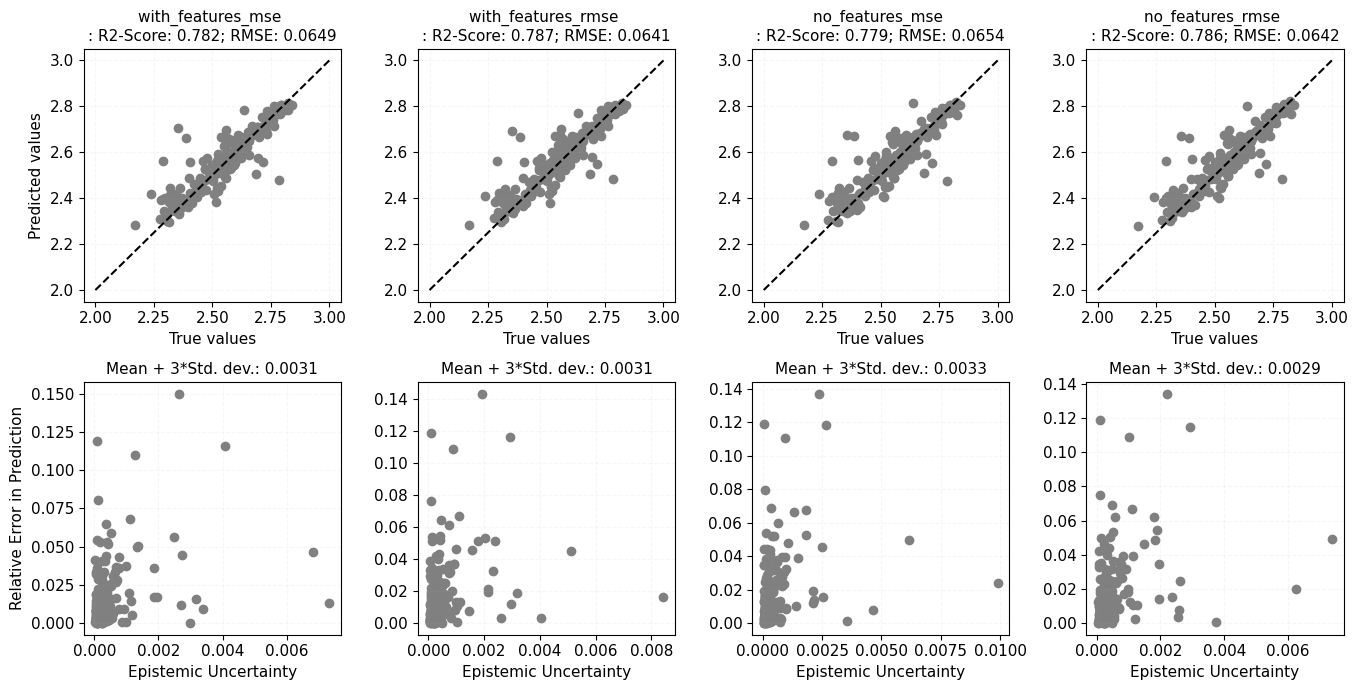

In [279]:
testing_results_fixed = {}
# visualize true vs predicted values and their corresponding uncertainities
# Set figure size in inches (width, height)
fig, ax = plt.subplots(2, 4, figsize=(13.7, 7))  # 174mm x 78mm
for i, name in enumerate(
    [
    'with_features_mse',
    'with_features_rmse',
    'no_features_mse',
    'no_features_rmse'
    ]
): 
    print(name)
    mean_pred = np.array(mean_pred_dict_testing_fixed[name].mean(axis=0))
    epistemic_unc = np.array(epistemic_unc_dict_testing_fixed[name]).reshape(-1, 1)
    rel_error_test = np.abs(df_smiles_test.loc[:, target_column].values - mean_pred) / df_smiles_test.loc[:, target_column].values
    outlier_threshold = np.mean(epistemic_unc) + 3*np.std(epistemic_unc)
    metrics_dict = get_performance_metrics(
        y_true=df_smiles_test.loc[:, target_column].values,
        y_pred=mean_pred
    )
    testing_results_fixed[name] = {
        'rmse': metrics_dict['rmse'],
        'r2_score': metrics_dict['r2_score'],
        'mean_epistemic_uncertainty': np.mean(epistemic_unc),
    }
    # plot true vs. predicted values
    ax[0][i].scatter(
        df_smiles_test.loc[:, target_column].values,
        mean_pred,
        color='gray'
    )
    ax[0][i].plot(
        [2, 3], [2, 3], color='black', linestyle='--'
    )
    # Set axis label and tick font sizes to 11 points
    ax[0][i].tick_params(axis='both', which='major', labelsize=11)
    ax[0][i].set_xlabel('True values', fontsize=11)
    if i == 0:
        ax[0][i].set_ylabel('Predicted values', fontsize=11)
    ax[0][i].grid(True, linestyle='--', alpha=0.1)
    ax[0][i].set_title(
        "{0} \n: R2-Score: {1:.3f}; RMSE: {2:.4f}".format(
            name,
            testing_results_fixed[name]['r2_score'],
            testing_results_fixed[name]['rmse']
        ),
        fontsize=11
    )
    # plot distribution of epistemic uncertainties
    ax[1][i].scatter(
        epistemic_unc,
        rel_error_test,
        color='gray'
    )
    ax[1][i].set_xlabel('Epistemic Uncertainty', fontsize=11)
    if i == 0:
        ax[1][i].set_ylabel('Relative Error in Prediction', fontsize=11)
    ax[1][i].tick_params(axis='both', which='major', labelsize=11)
    ax[1][i].set_title(
        "Mean + 3*Std. dev.: {0:.4f}".format(outlier_threshold),
        fontsize=11
    )
    ax[1][i].grid(True, linestyle='--', alpha=0.1)

#plt.suptitle("Testing data: True vs Predicted Values and Epistemic Uncertainties", fontsize=12)
plt.tight_layout()
# Save as EPS
plt.savefig(figs_dir / 'Chemprop_all_true_vs_predicted_and_uncertainties_testing_fixed.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()

## Ablation results

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


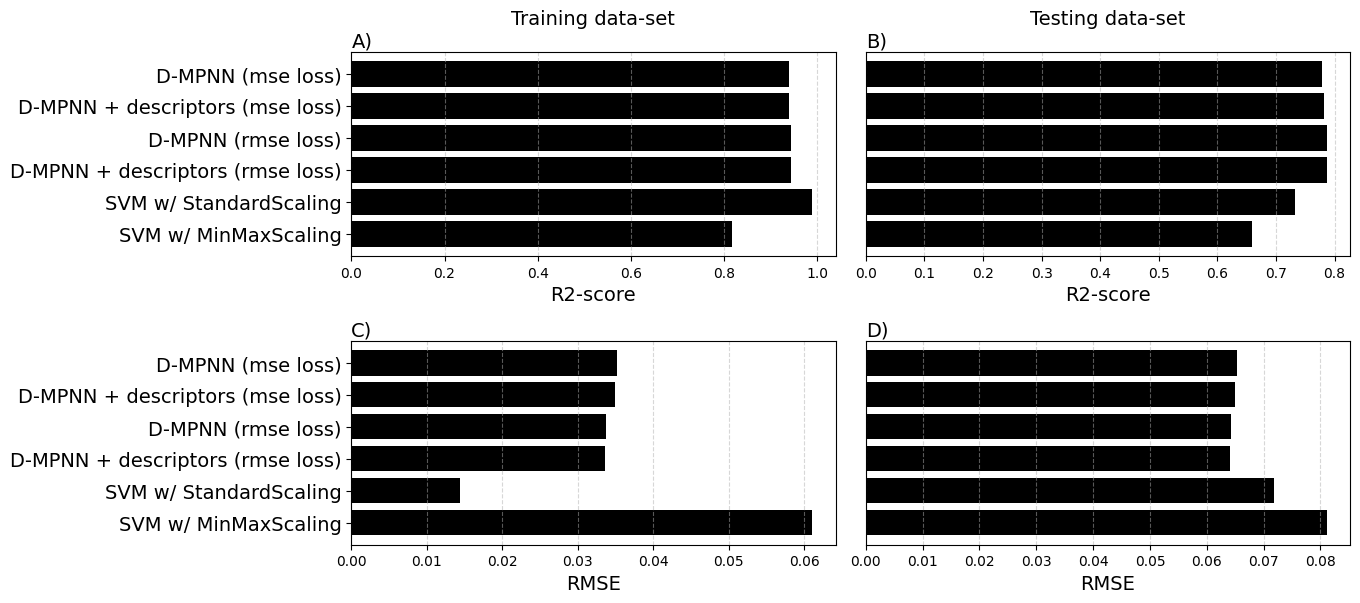

In [239]:
fig, ax = plt.subplots(2, 2, figsize=(13.7, 6.14))
model_labels = [
    'SVM w/ MinMaxScaling',
    'SVM w/ StandardScaling',
    'D-MPNN + descriptors (rmse loss)',
    'D-MPNN (rmse loss)',
    'D-MPNN + descriptors (mse loss)',
    'D-MPNN (mse loss)'
]
y_pos = [1, 2, 3, 4, 5, 6]
labels = ['A)', 'B)', 'C)', 'D)']
# Training R2
ax[0, 0].barh(y_pos, [
    svm_metrics_hjson['Training_MinMaxScaling']['r2_score'],
    svm_metrics_hjson['Training_StandardScaling']['r2_score'],
    training_results['with_features_rmse']['r2_score'],
    training_results['no_features_rmse']['r2_score'],
    training_results['with_features_mse']['r2_score'],
    training_results['no_features_mse']['r2_score'],
],
color='black'
)
ax[0, 0].set_yticks(y_pos, model_labels, fontsize=14)
ax[0, 0].set_xlabel('R2-score', fontsize=14)
ax[0, 0].set_title('Training data-set', fontsize=14, pad=20)
ax[0, 0].grid(axis='x', linestyle='--', alpha=0.5)

# Testing R2
ax[0, 1].barh(y_pos, [
    svm_metrics_hjson['Testing_MinMaxScaling']['r2_score'],
    svm_metrics_hjson['Testing_StandardScaling']['r2_score'],
    testing_results_fixed['with_features_rmse']['r2_score'],
    testing_results_fixed['no_features_rmse']['r2_score'],
    testing_results_fixed['with_features_mse']['r2_score'],
    testing_results_fixed['no_features_mse']['r2_score'],
], color='black')
ax[0, 1].set_xlabel('R2-score', fontsize=14)
ax[0, 1].set_title('Testing data-set', fontsize=14, pad=20)
ax[0, 1].set_yticks([])  # Only show y-ticks on left
ax[0, 1].grid(axis='x', linestyle='--', alpha=0.5)

# Training RMSE
ax[1, 0].barh(y_pos, [
    svm_metrics_hjson['Training_MinMaxScaling']['rmse'],
    svm_metrics_hjson['Training_StandardScaling']['rmse'],
    training_results['with_features_rmse']['rmse'],
    training_results['no_features_rmse']['rmse'],
    training_results['with_features_mse']['rmse'],
    training_results['no_features_mse']['rmse'],
], color='black')
ax[1, 0].set_yticks(y_pos, model_labels, fontsize=14)
ax[1, 0].set_xlabel('RMSE', fontsize=14)
ax[1, 0].grid(axis='x', linestyle='--', alpha=0.5)

# Testing RMSE
ax[1, 1].barh(y_pos, [
    svm_metrics_hjson['Testing_MinMaxScaling']['rmse'],
    svm_metrics_hjson['Testing_StandardScaling']['rmse'],
    testing_results_fixed['with_features_rmse']['rmse'],
    testing_results_fixed['no_features_rmse']['rmse'],
    testing_results_fixed['with_features_mse']['rmse'],
    testing_results_fixed['no_features_mse']['rmse'],
], color='black')
ax[1, 1].set_xlabel('RMSE', fontsize=14)
ax[1, 1].set_yticks([])
ax[1, 1].grid(axis='x', linestyle='--', alpha=0.5)

for idx, ax_ in enumerate(ax.flat):
    ax_.text(
        0, 1.1, labels[idx], 
        transform=ax_.transAxes, 
        fontsize=14, va='top', ha='left'
    )
#plt.suptitle('Performance Metrics for Training and Testing Sets', fontsize=12)
plt.tight_layout()
plt.savefig(figs_dir / 'performance_metrics_ablation_barplots_fixed.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()

## Best Model

R2-score:: 0.944
Root Mean Squared Error: 0.0338
R2-score:: 0.786
Root Mean Squared Error: 0.0642
Epistemic Uncertainty
Mean + 3*Std. dev. (training): 0.0014569819177268073
Mean + 3*Std. dev. (testing): 0.002938778547104448
Outlier threshold (training): 0.0015
Outlier threshold (testing): 0.0029
Absolute Relative Error
Mean + 3*Std. dev. (training): 0.04143866559208599
Mean + 3*Std. dev. (testing): 0.07740283278117814
Outlier threshold (training): 0.0414
Outlier threshold (testing): 0.0774


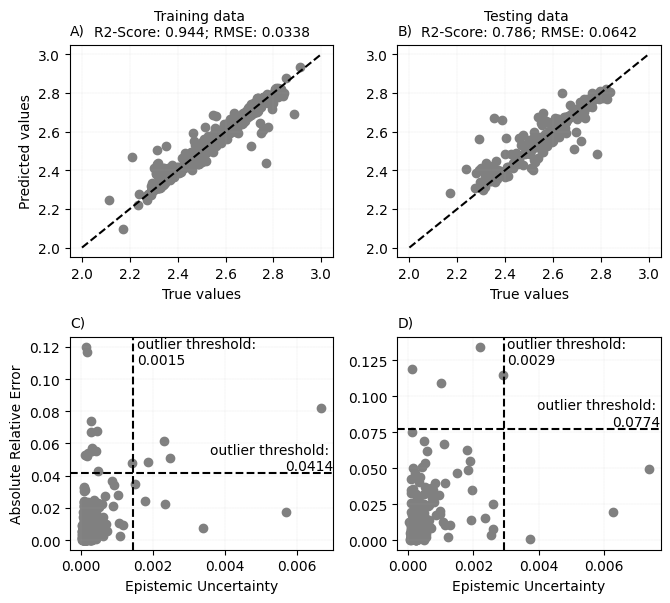

In [240]:
name_ = "no_features_rmse"
# visualize true vs predicted values and their corresponding uncertainities
# Set figure size in inches (width, height)
fig, ax = plt.subplots(2, 2, figsize=(6.85, 6.14))  # 174mm x 78mm
mean_pred_train = np.array(
    mean_pred_dict[name_].mean(axis=0)
)
epistemic_unc_train = np.array(epistemic_unc_dict[name_]).reshape(-1, 1)
metrics_dict_train = get_performance_metrics(
    y_true=train_ys,
    y_pred=mean_pred_train
)


mean_pred_test_fixed = np.array(
    mean_pred_dict_testing_fixed[name_].mean(axis=0)
)
epistemic_unc_test_fixed = np.array(epistemic_unc_dict_testing_fixed[name_]).reshape(-1, 1)
metrics_dict_test_fixed = get_performance_metrics(
    y_true=df_smiles_test.loc[:, target_column].values,
    y_pred=mean_pred_test_fixed
)

outlier_threshold_unc_train = np.mean(epistemic_unc_train) + 3*np.std(epistemic_unc_train)
outlier_threshold_unc_test_fixed = np.mean(epistemic_unc_test_fixed) + 3*np.std(epistemic_unc_test_fixed)
print("Epistemic Uncertainty")
print("Mean + 3*Std. dev. (training):", outlier_threshold_unc_train)
print("Mean + 3*Std. dev. (testing):", outlier_threshold_unc_test_fixed)
print("Outlier threshold (training): {0:.4f}".format(round(outlier_threshold_unc_train*10000)/10000))
print("Outlier threshold (testing): {0:.4f}".format(round(outlier_threshold_unc_test_fixed*10000)/10000))

rel_error_train = np.abs(train_ys - mean_pred_train) / train_ys
rel_error_test_fixed = np.abs(df_smiles_test.loc[:, target_column].values - mean_pred_test_fixed) / df_smiles_test.loc[:, target_column].values

outlier_threshold_err_train = np.mean(rel_error_train) + 3*np.std(rel_error_train)
outlier_threshold_err_test_fixed = np.mean(rel_error_test_fixed) + 3*np.std(rel_error_test_fixed)
print("Absolute Relative Error")
print("Mean + 3*Std. dev. (training):", outlier_threshold_err_train)
print("Mean + 3*Std. dev. (testing):", outlier_threshold_err_test_fixed)
print("Outlier threshold (training): {0:.4f}".format(round(outlier_threshold_err_train*10000)/10000))
print("Outlier threshold (testing): {0:.4f}".format(round(outlier_threshold_err_test_fixed*10000)/10000))
# plot true vs. predicted values
ax[0][0].scatter(
    train_ys,
    mean_pred_train,
    color='gray'
)
ax[0][0].plot(
    [2, 3], [2, 3], color='black', linestyle='--'
)
ax[0][0].tick_params(axis='both', which='major', labelsize=10)
ax[0][0].set_xlabel('True values', fontsize=10)
ax[0][0].set_ylabel('Predicted values', fontsize=10)
ax[0][0].grid(True, linestyle='--', linewidth=0.1)
ax[0][0].set_title(
    "Training data \nR2-Score: {0:.3f}; RMSE: {1:.4f}".format(
        training_results[name_]['r2_score'],
        training_results[name_]['rmse']
    ),
    fontsize=10
)

ax[0][1].scatter(
    df_smiles_test.loc[:, target_column].values,
    mean_pred_test_fixed,
    color='gray'
)
ax[0][1].plot(
    [2, 3], [2, 3], color='black', linestyle='--'
)
# Set axis label and tick font sizes to 10 points
ax[0][1].tick_params(axis='both', which='major', labelsize=10)
ax[0][1].set_xlabel('True values', fontsize=10)
    
ax[0][1].grid(True, linestyle='--', linewidth=0.1)
ax[0][1].set_title(
    "Testing data \nR2-Score: {0:.3f}; RMSE: {1:.4f}".format(
        testing_results_fixed[name_]['r2_score'],
        testing_results_fixed[name_]['rmse']
    ),
    fontsize=10
)
# plot distribution of epistemic uncertainties
ax[1][0].scatter(
    epistemic_unc_train,
    rel_error_train,
    color='gray'
)
ax[1][0].axvline(outlier_threshold_unc_train, color='black', linestyle='--')
ax[1][0].axhline(outlier_threshold_err_train, color='black', linestyle='--')
ax[1][0].grid(True, linestyle='--', linewidth=0.1)
ax[1][0].set_xlabel('Epistemic Uncertainty', fontsize=10)
ax[1][0].set_ylabel('Absolute Relative Error', fontsize=10)
ax[1][0].tick_params(axis='both', which='major', labelsize=10)
ax[1][0].text(
    outlier_threshold_unc_train + 0.0001, ax[1][0].get_ylim()[1],
    f"outlier threshold: \n{outlier_threshold_unc_train:.4f}",
    color='black', fontsize=10, ha='left', va='top', rotation=0,
    )
ax[1][0].text(
    ax[1][0].get_xlim()[1], outlier_threshold_err_train,
    f"outlier threshold: \n{outlier_threshold_err_train:.4f}",
    color='black', fontsize=10, ha='right', va='bottom', rotation=0,
    )
ax[1][1].scatter(
    epistemic_unc_test_fixed,
    rel_error_test_fixed,
    color='gray'
)
ax[1][1].grid(True, linestyle='--', linewidth=0.1)
ax[1][1].set_xlabel('Epistemic Uncertainty', fontsize=10)
ax[1][1].tick_params(axis='both', which='major', labelsize=10)
ax[1][1].axvline(outlier_threshold_unc_test_fixed, color='black', linestyle='--')
ax[1][1].axhline(outlier_threshold_err_test_fixed, color='black', linestyle='--')
ax[1][1].text(
    outlier_threshold_unc_test_fixed+0.0001, ax[1][1].get_ylim()[1],
    f"outlier threshold: \n{outlier_threshold_unc_test_fixed:.4f}",
    color='black', fontsize=10, ha='left', va='top', rotation=0,
    )
ax[1][1].text(
    ax[1][1].get_xlim()[1], outlier_threshold_err_test_fixed,
    f"outlier threshold: \n{outlier_threshold_err_test_fixed:.4f}",
    color='black', fontsize=10, ha='right', va='bottom', rotation=0,
    )
labels = ['A)', 'B)', 'C)', 'D)']
for idx, ax_ in enumerate(ax.flat):
    ax_.text(
        0, 1.1, labels[idx], 
        transform=ax_.transAxes, 
        fontsize=10, va='top', ha='left'
    )
#plt.suptitle("Ensemble of D-MPNN models:True vs Predicted Values and Epistemic Uncertainties", fontsize=12)
plt.tight_layout()
plt.savefig(figs_dir / 'Chemprop_no_features_rmse_true_vs_predicted_and_uncertainties_fixed.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()

**Category 1: Low uncertainity and low relative error**

In [241]:
((epistemic_unc_train < 0.0015) & (rel_error_train < 0.0414)).sum()

661

In [242]:
((epistemic_unc_test_fixed < 0.003) & (rel_error_test_fixed < 0.0773)).sum()

212

**Category 2: Low uncertainity and high relative error**

In [243]:
((epistemic_unc_train < 0.0015) & (rel_error_train > 0.0414)).sum()

13

In [244]:
epistemic_unc_train[
    (epistemic_unc_train < 0.0015) & (rel_error_train > 0.0414)
]

array([0.00027874, 0.00015912, 0.00030714, 0.0001918 , 0.00045319,
       0.0002995 , 0.00142789, 0.00011665, 0.00027874, 0.00047394,
       0.00043404, 0.00016943, 0.00016328], dtype=float32)

In [245]:
((epistemic_unc_test_fixed < 0.003) & (rel_error_test_fixed > 0.0773)).sum()

4

In [246]:
epistemic_unc_test_fixed[
    (epistemic_unc_test_fixed < 0.003) & (rel_error_test_fixed > 0.0773)
]

array([0.0010101 , 0.00292382, 0.0001126 , 0.00219505], dtype=float32)

In [247]:
rel_error_test_fixed[
    (epistemic_unc_test_fixed < 0.003) & (rel_error_test_fixed > 0.0773)
]

array([0.1091127 , 0.11449317, 0.11876273, 0.13427895])

**Category 3: High uncertainity and low relative error**

In [248]:
((epistemic_unc_train > 0.0015) & (rel_error_train < 0.0414)).sum()

5

In [249]:
epistemic_unc_train[
    (epistemic_unc_train > 0.0015) & (rel_error_train < 0.0414)
]

array([0.0023334 , 0.00152036, 0.00177789, 0.00339541, 0.00569512],
      dtype=float32)

In [250]:
rel_error_train[
    (epistemic_unc_train > 0.0015) & (rel_error_train < 0.0414)
]

array([0.02252684, 0.03476607, 0.02410386, 0.00777005, 0.01738492])

In [251]:
((epistemic_unc_test_fixed > 0.003) & (rel_error_test_fixed < 0.0773)).sum()

3

In [252]:
epistemic_unc_test_fixed[
    (epistemic_unc_test_fixed > 0.003) & (rel_error_test_fixed < 0.0773)
]

array([0.00374782, 0.00737746, 0.00626807], dtype=float32)

In [253]:
rel_error_test_fixed[
    (epistemic_unc_test_fixed > 0.003) & (rel_error_test_fixed < 0.0773)
]

array([0.00075606, 0.04911878, 0.01976627])

**Category 4: High uncertainity and high relative error**

In [254]:
epistemic_unc_train[
    (epistemic_unc_train > 0.0015) & (rel_error_train > 0.0414)
]

array([0.00667891, 0.0018677 , 0.00247997, 0.00231406], dtype=float32)

In [255]:
rel_error_train[
    (epistemic_unc_train > 0.0015) & (rel_error_train > 0.0414)
]

array([0.08205828, 0.04861581, 0.05111404, 0.06172917])

In [256]:
df_smiles_train[
    (epistemic_unc_train > 0.0015) & (rel_error_train > 0.0414)
]

,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean,Moleculer Weight,Proxy for Free Volume,Rotatable Bonds,Aromatic Rings,Topological Polar Surface Area,H-Bond Donors,H-Bond Acceptors
81,98,JPS_10,2.3139,T,C,oxyethylene,OCC,PubChem,OCC,oxyethylene,CCO,46.069,15.347288,0,0,20.23,1,1
312,419,BWN_28,2.2989,T,H,"1,1-dimethylethylene",CC(=C)C,PubChemPy,CC(=C)C,"1,1-dimethylethylene",C=C(C)C,56.108,14.015650,0,0,0.00,0,0
318,427,BWN_95,2.3139,T,H,propylene oxide,CC1CO1,PubChemPy,CC1CO1,propylene oxide,CC1CO1,58.080,14.510466,0,0,12.53,0,1
504,669,NS_001,2.1139,T,S,oxy(diethylsilylene),[SiH](O)(CC)CC,Reference,[SiH](O)(CC)CC,oxy(diethylsilylene),CC[SiH](O)CC,104.225,17.344290,2,0,20.23,1,1


In [257]:
((epistemic_unc_test_fixed > 0.003) & (rel_error_test_fixed > 0.0773)).sum()

0

## Applicability Domain Analysis with fixed test set

In [258]:
test_data_loader_fixed = prep_data_loader(
    smis_=test_smis_fixed
)

In [259]:
test_data_encodings_fixed = get_MPNN_encodings(
    model_ensemble_=ensemble_no_features_rmse,
    data_loader_=test_data_loader_fixed
)

In [260]:
h_test_mean_fixed = test_data_encodings_fixed.mean(dim=0)
h_test_mean_fixed.shape

torch.Size([219, 300])

In [261]:
# If mean_encodings is a torch tensor, convert to numpy
h_test_mean_np_fixed = h_test_mean_fixed.cpu().numpy()  # shape: (683, 300)

h_test_mean_scaled_fixed = scaler.transform(h_test_mean_np_fixed)

In [262]:
leverage_train, leverage_test_fixed = calculate_leverage_values(
    X_train=h_train_mean_scaled,
    X_test=h_test_mean_scaled_fixed
)

In [263]:
leverage_test_fixed.max()

14.546574615195158

In [264]:
leverage_train.max()

0.9999486630020237

In [265]:
# find outliers based on leverage values
leverage_threshold = 3 *(300+1)/len(leverage_train)

print("Leverage threshold: {:.3f}".format(leverage_threshold))

outliers = np.where(leverage_test_fixed > leverage_threshold)[0]
within_leverage_threshold = np.where(leverage_test_fixed <= leverage_threshold)[0]
print('Testing data')
print("Number of outliers: ", len(outliers))
print("Number within leverage threshold: ", len(within_leverage_threshold))

Leverage threshold: 1.322
Testing data
Number of outliers:  59
Number within leverage threshold:  160


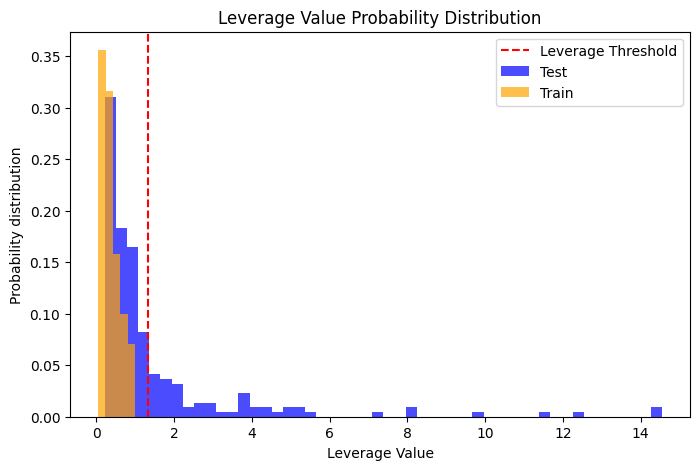

In [266]:
## Compute histogram counts
counts_train, bins_train = np.histogram(leverage_train, bins=5)
counts_test_fixed, bins_test_fixed = np.histogram(leverage_test_fixed, bins=50)

# Normalize so max height is 1
probs_train = counts_train / counts_train.sum()
probs_test_fixed = counts_test_fixed / counts_test_fixed.sum()

plt.figure(figsize=(8, 5))
plt.bar(bins_test_fixed[:-1], probs_test_fixed, width=np.diff(bins_test_fixed), alpha=0.7, label='Test', align='edge', color='blue')
plt.bar(bins_train[:-1], probs_train, width=np.diff(bins_train), alpha=0.7, label='Train', align='edge', color='orange')
plt.axvline(leverage_threshold, color='red', linestyle='--', label='Leverage Threshold')
plt.xlabel('Leverage Value')
plt.ylabel('Probability distribution')
plt.title('Leverage Value Probability Distribution')
plt.legend()
plt.show()

In [267]:
mahal_train, mahal_test_fixed = calculate_mahalanobis_ad(h_train_mean_scaled, h_test_mean_scaled_fixed)
mahal_threshold = np.percentile(mahal_train, 95) if mahal_train is not None else None
if mahal_train is not None:
    print(f"Mahalanobis threshold: {mahal_threshold}")
    print(f"Test samples outside AD (Mahalanobis): {np.sum(mahal_test_fixed > mahal_threshold)}/{len(mahal_test_fixed)}")

Mahalanobis threshold: 22.888767993743933
Test samples outside AD (Mahalanobis): 64/219


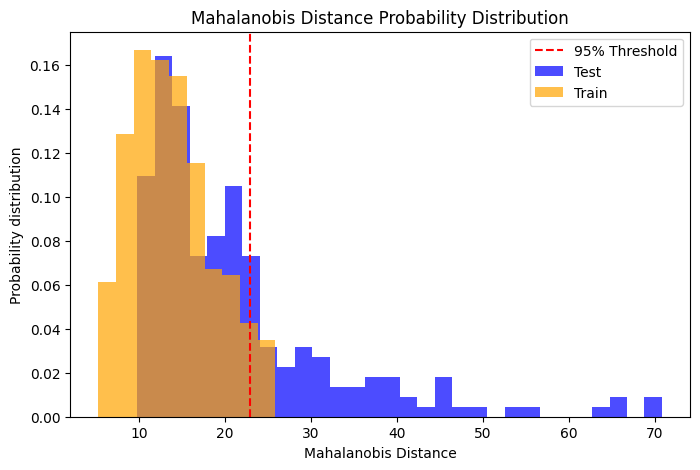

In [268]:
# Compute histogram counts for train and test
counts_train, bins_train = np.histogram(mahal_train, bins=10)
counts_test_fixed, bins_test_fixed = np.histogram(mahal_test_fixed, bins=30)

# Normalize so the sum of heights is 1 (probability distribution)
probs_train = counts_train / counts_train.sum()
probs_test_fixed = counts_test_fixed / counts_test_fixed.sum()
plt.figure(figsize=(8, 5))
plt.bar(bins_test_fixed[:-1], probs_test_fixed, width=np.diff(bins_test_fixed), alpha=0.7, label='Test', align='edge', color='blue')
plt.bar(bins_train[:-1], probs_train, width=np.diff(bins_train), alpha=0.7, label='Train', align='edge', color='orange')
plt.axvline(mahal_threshold, color='red', linestyle='--', label='95% Threshold')
plt.xlabel('Mahalanobis Distance')
plt.ylabel('Probability distribution')
plt.title('Mahalanobis Distance Probability Distribution')
plt.legend()
plt.show()

In [269]:
# Replace X_train_scaled, X_test_scaled, y_train, y_test with your actual variables
knn_results_fixed = calculate_knn_ad(h_train_mean_scaled, h_test_mean_scaled_fixed)
print("\nkNN Applicability Domain Results:")
for k, results in knn_results_fixed.items():
    threshold = results['threshold']
    outside_ad = np.sum(results['test_distances'] > threshold)
    print(f"k={k}: threshold={threshold:.4f}, outside AD: {outside_ad}/{len(results['test_distances'])}")


kNN Applicability Domain Results:
k=3: threshold=14.8760, outside AD: 13/219
k=5: threshold=16.3946, outside AD: 12/219
k=10: threshold=18.3286, outside AD: 10/219


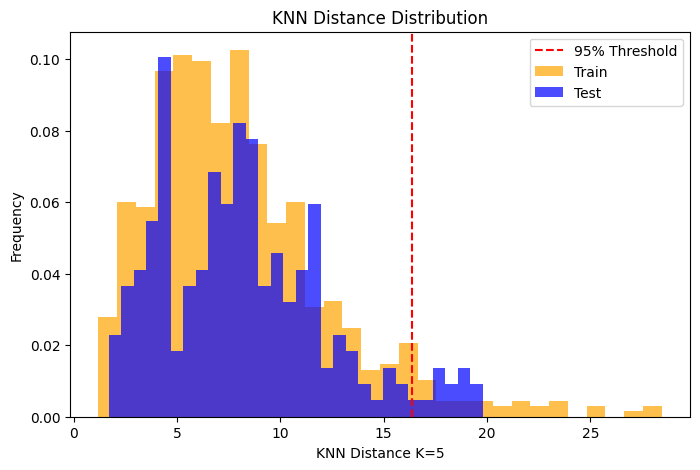

In [270]:
# Compute histogram counts for train and test
counts_train, bins_train = np.histogram(knn_results_fixed[5]['train_distances'], bins=30)
counts_test_fixed, bins_test_fixed = np.histogram(knn_results_fixed[5]['test_distances'], bins=30)

# Normalize so the sum of heights is 1 (probability distribution)
probs_train = counts_train / counts_train.sum()
probs_test_fixed = counts_test_fixed / counts_test_fixed.sum()
# visualize mahalanobis AD results
plt.figure(figsize=(8, 5))
plt.bar(bins_train[:-1], probs_train, width=np.diff(bins_train), alpha=0.7, label='Train', align='edge', color='orange')
plt.bar(bins_test_fixed[:-1], probs_test_fixed, width=np.diff(bins_test_fixed), alpha=0.7, label='Test', align='edge', color='blue')
plt.axvline(knn_results_fixed[5]['threshold'], color='red', linestyle='--', label='95% Threshold')
plt.xlabel('KNN Distance K=5')
plt.ylabel('Frequency')
plt.title('KNN Distance Distribution')
plt.legend()
plt.show()

In [271]:
# --- Calculate AD metrics ---
X_train_pca, X_test_pca_fixed, t2_train, t2_test_fixed, pca_model = calculate_pca_ad(h_train_mean_scaled, h_test_mean_scaled_fixed)
t2_threshold = np.percentile(t2_train, 95)
print(f"T² threshold: {t2_threshold}")
print(f"Test samples outside AD (T²): {np.sum(t2_test_fixed > t2_threshold)}/{len(t2_test_fixed)}")

T² threshold: 2.5438913106918335
Test samples outside AD (T²): 12/219


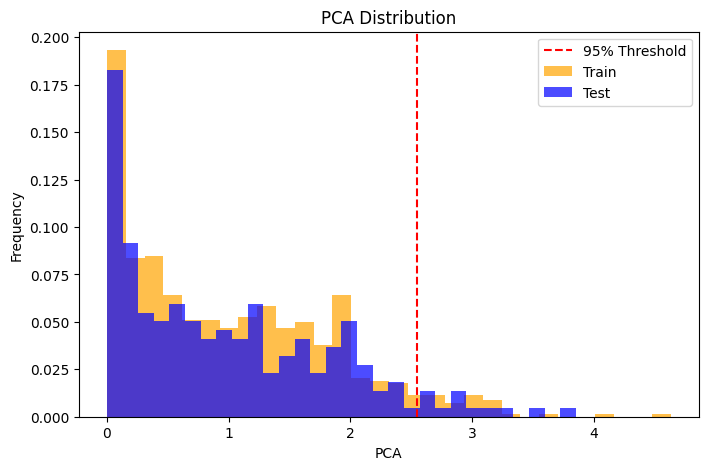

In [272]:
# Compute histogram counts for train and test
counts_train, bins_train = np.histogram(t2_train, bins=30)
counts_test_fixed, bins_test_fixed = np.histogram(t2_test_fixed, bins=30)

# Normalize so the sum of heights is 1 (probability distribution)
probs_train = counts_train / counts_train.sum()
probs_test_fixed = counts_test_fixed / counts_test_fixed.sum()
# visualize mahalanobis AD results
plt.figure(figsize=(8, 5))
plt.bar(bins_train[:-1], probs_train, width=np.diff(bins_train), alpha=0.7, label='Train', align='edge', color='orange')
plt.bar(bins_test_fixed[:-1], probs_test_fixed, width=np.diff(bins_test_fixed), alpha=0.7, label='Test', align='edge', color='blue')
plt.axvline(t2_threshold, color='red', linestyle='--', label='95% Threshold')
plt.xlabel('PCA')
plt.ylabel('Frequency')
plt.title('PCA Distribution')
plt.legend()
plt.show()

/tmp/ipykernel_665869/721311928.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1][0].legend(loc='upper right', fontsize=12)
/tmp/ipykernel_665869/721311928.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1][1].legend(loc='upper left', fontsize=12)
/tmp/ipykernel_665869/721311928.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1][2].legend(loc='upper left', fontsize=12)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


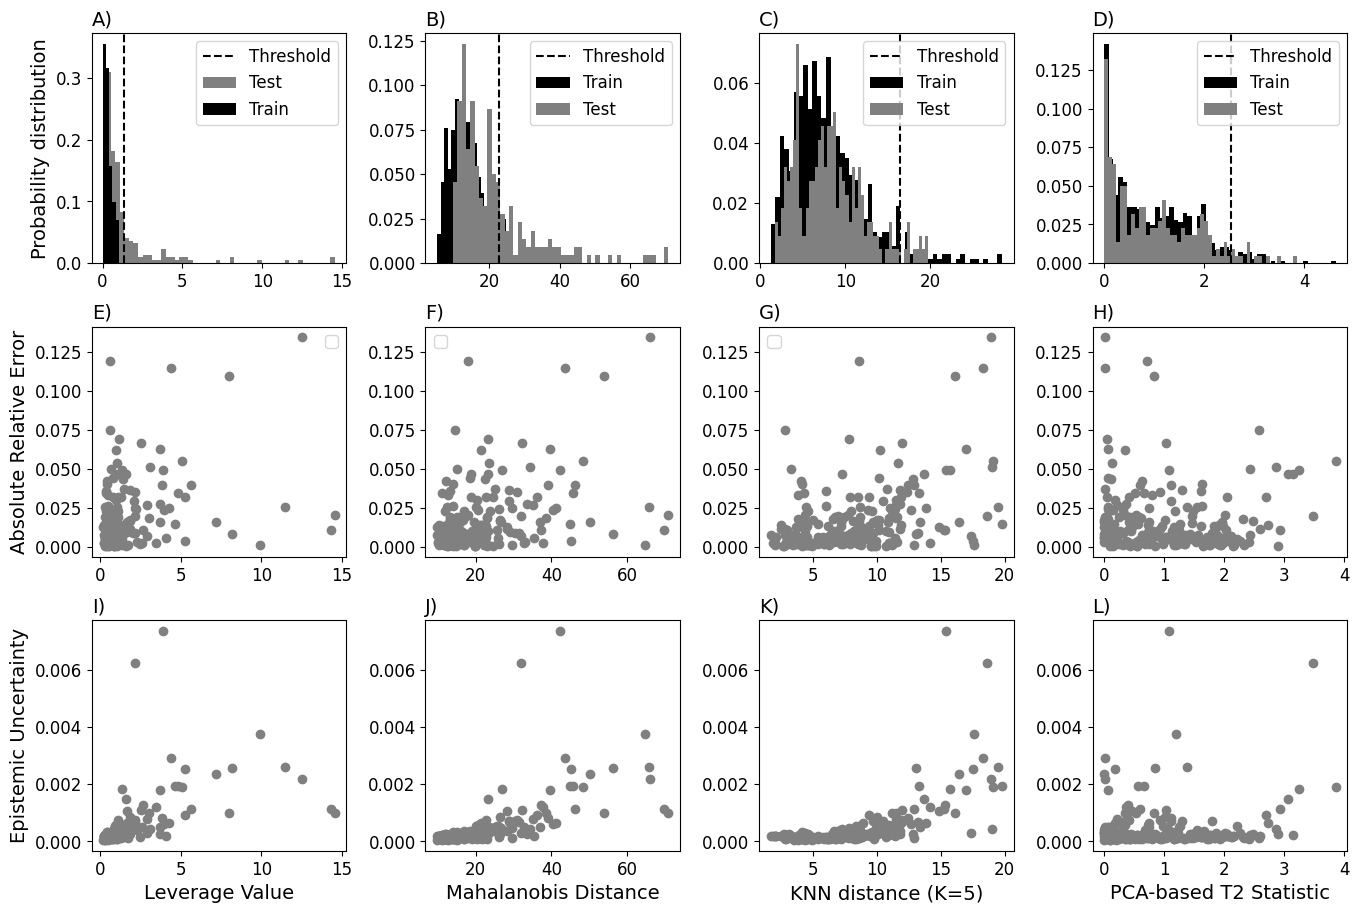

In [275]:
fig, ax = plt.subplots(3, 4, figsize=(13.7, 9.21))  # 174mm x 78mm
## Compute histogram counts
counts_train, bins_train = np.histogram(leverage_train, bins=5)
counts_test_fixed, bins_test_fixed = np.histogram(leverage_test_fixed, bins=50)

# Normalize so max height is 1
probs_train = counts_train / counts_train.sum()
probs_test_fixed = counts_test_fixed / counts_test_fixed.sum()
ax[0][0].bar(
    bins_test_fixed[:-1], probs_test_fixed, width=np.diff(bins_test_fixed), label='Test', align='edge', color='gray'
)
ax[0][0].bar(
    bins_train[:-1], probs_train, width=np.diff(bins_train), label='Train', align='edge', color='black'
)
ax[0][0].axvline(leverage_threshold, color='black', linestyle='--', label='Threshold')
ax[0][0].set_ylabel('Probability distribution',fontsize=14)
ax[0][0].legend(fontsize=12)
ax[0][0].tick_params(axis='both', which='major', labelsize=12)

## Compute histogram counts
counts_train, bins_train = np.histogram(mahal_train, bins=20)
counts_test_fixed, bins_test_fixed = np.histogram(mahal_test_fixed, bins=50)

# Normalize so max height is 1
probs_train = counts_train / counts_train.sum()
probs_test_fixed = counts_test_fixed / counts_test_fixed.sum()
ax[0][1].bar(bins_train[:-1], probs_train, width=np.diff(bins_train), label='Train', align='edge', color='black')
ax[0][1].bar(bins_test_fixed[:-1], probs_test_fixed, width=np.diff(bins_test_fixed), label='Test', align='edge', color='gray')
ax[0][1].axvline(mahal_threshold, color='black', linestyle='--', label='Threshold')
ax[0][1].legend(fontsize=12)
ax[0][1].tick_params(axis='both', which='major', labelsize=12)


# Compute histogram counts
counts_train, bins_train = np.histogram(knn_results_fixed[5]['train_distances'], bins=50)
counts_test_fixed, bins_test_fixed = np.histogram(knn_results_fixed[5]['test_distances'], bins=50)

# Normalize so max height is 1
probs_train = counts_train / counts_train.sum()
probs_test_fixed = counts_test_fixed / counts_test_fixed.sum()
ax[0][2].bar(bins_train[:-1], probs_train, width=np.diff(bins_train), label='Train', align='edge', color='black')
ax[0][2].bar(bins_test_fixed[:-1], probs_test_fixed, width=np.diff(bins_test_fixed), label='Test', align='edge', color='gray')
ax[0][2].axvline(knn_results_fixed[5]['threshold'], color='black', linestyle='--', label='Threshold')
ax[0][2].legend(fontsize=12)
ax[0][2].tick_params(axis='both', which='major', labelsize=12)

# Compute histogram counts
counts_train, bins_train = np.histogram(t2_train, bins=50)
counts_test_fixed, bins_test_fixed = np.histogram(t2_test_fixed, bins=50)

# Normalize so max height is 1
probs_train = counts_train / counts_train.sum()
probs_test_fixed = counts_test_fixed / counts_test_fixed.sum()
ax[0][3].bar(bins_train[:-1], probs_train, width=np.diff(bins_train), label='Train', align='edge', color='black')
ax[0][3].bar(bins_test_fixed[:-1], probs_test_fixed, width=np.diff(bins_test_fixed), label='Test', align='edge', color='gray')
ax[0][3].axvline(t2_threshold, color='black', linestyle='--', label='Threshold')
ax[0][3].legend(fontsize=12)
ax[0][3].tick_params(axis='both', which='major', labelsize=12)

ax[1][0].scatter(
    leverage_test_fixed,
    rel_error_test_fixed,
    color='gray'
)
ax[1][0].set_ylabel('Absolute Relative Error', fontsize=14)
ax[1][0].legend(loc='upper right', fontsize=12)
ax[1][0].tick_params(axis='both', which='major', labelsize=12)


ax[1][1].scatter(
    mahal_test_fixed,
    rel_error_test_fixed,
    color='gray'
)
ax[1][1].legend(loc='upper left', fontsize=12)
ax[1][1].tick_params(axis='both', which='major', labelsize=12)

ax[1][2].scatter(
    knn_results_fixed[5]['test_distances'],
    rel_error_test_fixed,
    color='gray'
)
ax[1][2].legend(loc='upper left', fontsize=12)
ax[1][2].tick_params(axis='both', which='major', labelsize=12)

ax[1][3].scatter(
    t2_test_fixed,
    rel_error_test_fixed,
    color='gray'
)
ax[1][3].tick_params(axis='both', which='major', labelsize=12)

ax[2][0].scatter(
    leverage_test_fixed,
    epistemic_unc_test_fixed,
    color='gray'
)
ax[2][0].set_xlabel('Leverage Value', fontsize=14)
ax[2][0].set_ylabel('Epistemic Uncertainty', fontsize=14)
ax[2][0].tick_params(axis='both', which='major', labelsize=12)

ax[2][1].scatter(
    mahal_test_fixed,
    epistemic_unc_test_fixed,
    color='gray'
)
ax[2][1].set_xlabel('Mahalanobis Distance', fontsize=14)
ax[2][1].tick_params(axis='both', which='major', labelsize=12)

ax[2][2].scatter(
    knn_results_fixed[5]['test_distances'],
    epistemic_unc_test_fixed,
    color='gray'
)
ax[2][2].set_xlabel('KNN distance (K=5)', fontsize=14)
ax[2][2].tick_params(axis='both', which='major', labelsize=12)

ax[2][3].scatter(
    t2_test_fixed,
    epistemic_unc_test_fixed,
    color='gray'
)
ax[2][3].set_xlabel('PCA-based T2 Statistic', fontsize=14)
ax[2][3].tick_params(axis='both', which='major', labelsize=12)

for idx, ax_ in enumerate(ax.flat):
    ax_.text(
        0, 1.1, f"{chr(65+idx)})",
        transform=ax_.transAxes,
        fontsize=14, va='top', ha='left'
    )
#plt.suptitle('Applicability Domain Analysis', fontsize=12)
plt.tight_layout()
plt.savefig(
    figs_dir / 'applicability_domain_analysis_plots_fixed.eps',
    format='eps',
    bbox_inches='tight'
)
plt.show()
plt.close()

---

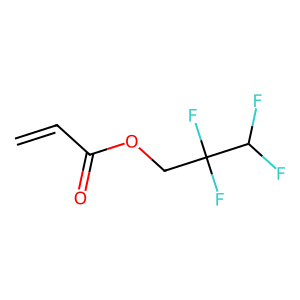

In [280]:
from rdkit import Chem
from rdkit.Chem import Draw

# SMILES string
smiles = "C=CC(=O)OCC(F)(F)C(F)F"

# Create RDKit molecule object
mol = Chem.MolFromSmiles(smiles)

# Draw the molecular graph
Draw.MolToImage(mol)

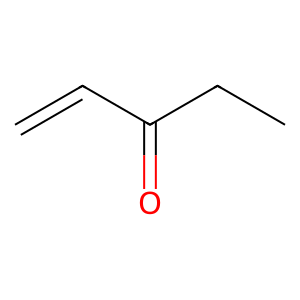

In [281]:
# SMILES string
smiles = "C=CC(=O)CC"

# Create RDKit molecule object
mol = Chem.MolFromSmiles(smiles)

# Draw the molecular graph
Draw.MolToImage(mol)

Text(0, 0.5, 'Probability Density')

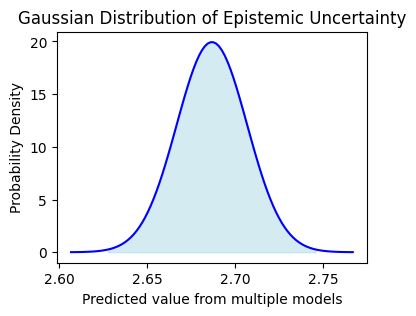

In [286]:
# draw a gaussian distribution with mean and std dev of one of test samples
import numpy as np
import matplotlib.pyplot as plt
mean_value = 2.6868
std_dev = 0.02
x = np.linspace(mean_value - 4*std_dev, mean_value + 4*std_dev, 100)
y = (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean_value) / std_dev) ** 2)
plt.figure(figsize=(4, 3))
plt.plot(x, y, color='blue')
plt.fill_between(x, y, where=(x >= mean_value - 3*std_dev
) & (x <= mean_value + 3*std_dev), color='lightblue', alpha=0.5, label='±3 Std Dev')
plt.title('Gaussian Distribution of Epistemic Uncertainty')
plt.xlabel('Predicted value from multiple models')
plt.ylabel('Probability Density')
